In [1]:
from scripts.imports import *
from rasterio.enums import Resampling
from shapely.geometry import Polygon, Point
from pyproj import Transformer
import os
import re
import gc
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------------
# positions for SR bands in your stacks (already reflectance)
L7_SR_IDX = slice(0, 6)   # SR_B1..SR_B5, SR_B7
L8_SR_IDX = slice(0, 7)   # SR_B1..SR_B7

USE_SIMULATED_TRACKS = True
PLOT_RGB_IMAGE = False
PLOT_SIMULATED_TRACKS = True
APPLY_MIN_FILTERED_FRACTION_TO_GRID_CELLS = True

PLOT_SNOW_PRODUCT_MAPS = False
PLOT_SALOMONSON_MAP = False

# Folder containing your reflectance Landsat stacks
LANDSAT_FOLDER = '../scratch/data/landsat_oursites_L1_GEE/TOA/'

# Topography data
LANDSAT_MASKING_FOLDER = '../scratch/data/landsat_masking/'

# WorldCover data
WC_FOLDER = '../scratch/data/WC/'
WC_FOREST_VALUE = 10

WC_NAME_MAP = {
    "sodankyla": "sodankyla_full",
    "marcell": "marcell_MN",
    "oregon": "oregon_yp",
}

# ROI options
USE_ROI = False
ROI_LON = -105.90
ROI_LAT = 53.92
ROI_HALF_WIDTH_M = 26000
ROI_HALF_HEIGHT_M = 26000

# Simulated ICESat-2 settings
N_TRACK_SIMS = 1
ICESAT2_PAIR_SPACING_M = 3300
ICESAT2_INCLINATION_DEG = 92
TRACK_LAT_BINS = 8
TRACK_BOX_SIZE_M = 1000
TRACK_MIN_FILTERED_FRACTION = 0.2
RNG_SEED = 42
N_BEAM_PAIRS = 1

# Regular grid-cell mode settings
GRID_N_X = 8
GRID_N_Y = 8
GRID_CELL_SIZE_M = 1000

# Spectral variables to summarise within each sampled cell.
# These include all direct inputs to the Dozier and Klein algorithms,
# plus the source bands used to calculate NDSI and NDVI.
SPECTRAL_VARIABLES = (
    "ndsi",
    "ndvi",
    "green",
    "red",
    "nir",
    "swir",
)


# ------------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------------
def _sr_slice(landsat_type):
    return L7_SR_IDX if landsat_type == 'Landsat7' else L8_SR_IDX


def extract_core_sr(landsat_da, landsat_type):
    """
    Return blue, green, red, nir, swir1 as reflectance,
    with consistent meanings across sensors.
    """
    if landsat_type == 'Landsat7':
        blue  = landsat_da.isel(band=0)
        green = landsat_da.isel(band=1)
        red   = landsat_da.isel(band=2)
        nir   = landsat_da.isel(band=3)
        swir1 = landsat_da.isel(band=4)
    else:
        blue  = landsat_da.isel(band=1)
        green = landsat_da.isel(band=2)
        red   = landsat_da.isel(band=3)
        nir   = landsat_da.isel(band=4)
        swir1 = landsat_da.isel(band=5)

    return blue, green, red, nir, swir1


def find_masks(masking_folder, wc_folder, cam):
    """
    Find:
      - WorldCover landcover from WC_FOLDER
      - ALOS elevation / gradient / aspect from LANDSAT_MASKING_FOLDER
    """
    wc_cam_name = WC_NAME_MAP.get(cam, cam)
    landcover_filepath = os.path.join(wc_folder, f"{wc_cam_name}.tif")

    elevation_filepath = None
    gradient_filepath = None
    aspect_filepath = None

    for filename in os.listdir(masking_folder):
        filename_lower = filename.lower()

        if (
            cam in filename
            and "elevation" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            elevation_filepath = os.path.join(masking_folder, filename)

        elif (
            cam in filename
            and "gradient" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            gradient_filepath = os.path.join(masking_folder, filename)

        elif (
            cam in filename
            and "aspect" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            aspect_filepath = os.path.join(masking_folder, filename)

    if (
        not os.path.exists(landcover_filepath)
        or elevation_filepath is None
        or gradient_filepath is None
        or aspect_filepath is None
    ):
        raise FileNotFoundError(
            f"Could not find all required files for {cam}\n"
            f"  WorldCover expected: {landcover_filepath}\n"
            f"  ALOS elevation found: {elevation_filepath}\n"
            f"  ALOS gradient found:  {gradient_filepath}\n"
            f"  ALOS aspect found:    {aspect_filepath}"
        )

    return landcover_filepath, elevation_filepath, gradient_filepath, aspect_filepath


def load_and_reproject_to_landsat(source_path, match_array, band_name, method=Resampling.nearest):
    """
    Minimal memory-safe version of the original function.

    The important change is that the source raster is closed after
    reproject_match has created the matched output.
    """
    src = rioxarray.open_rasterio(source_path, masked=True).squeeze()
    src.name = band_name

    try:
        out = src.rio.reproject_match(match_array, resampling=method)
        out.name = band_name
    finally:
        try:
            src.close()
        except Exception:
            pass
        del src

    return out


def subset_roi(da, centre_lon, centre_lat, half_width_m, half_height_m):
    """
    Subset a DataArray to a rectangular ROI around lon/lat,
    using the dataset's CRS and units.
    """
    if da.rio.crs is None:
        raise ValueError("Dataset has no CRS; cannot subset by lon/lat.")

    transformer = Transformer.from_crs("EPSG:4326", da.rio.crs, always_xy=True)
    cx, cy = transformer.transform(centre_lon, centre_lat)

    minx = cx - half_width_m
    maxx = cx + half_width_m
    miny = cy - half_height_m
    maxy = cy + half_height_m

    return da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)


def combine_tifs(
    landsat_filepath,
    landcover_filepath,
    elevation_filepath,
    gradient_filepath,
    aspect_filepath,
    landsat_type,
    use_roi=False
):
    """
    Load Landsat reflectance stack + WorldCover landcover + elevation
    + gradient + aspect, all on the same Landsat grid.
    """
    landsat = rioxarray.open_rasterio(landsat_filepath, masked=True).squeeze()
    landsat.name = "landsat"

    if use_roi:
        print("  Applying ROI crop to Landsat...")
        landsat = subset_roi(
            landsat,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

    landcover = load_and_reproject_to_landsat(
        landcover_filepath,
        landsat,
        "landcover",
        method=Resampling.nearest
    )

    elevation = load_and_reproject_to_landsat(
        elevation_filepath,
        landsat,
        "elevation",
        method=Resampling.bilinear
    )

    gradient = load_and_reproject_to_landsat(
        gradient_filepath,
        landsat,
        "gradient",
        method=Resampling.bilinear
    )

    aspect = load_and_reproject_to_landsat(
        aspect_filepath,
        landsat,
        "aspect",
        method=Resampling.nearest
    )

    if use_roi:
        landcover = subset_roi(
            landcover,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        elevation = subset_roi(
            elevation,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        gradient = subset_roi(
            gradient,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        aspect = subset_roi(
            aspect,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

    ds = xr.merge([landsat, landcover, elevation, gradient, aspect])

    # Remove local references. The merged Dataset keeps what it needs.
    del landcover, elevation, gradient, aspect

    return ds


def apply_valid_mask(ds, e=80):
    elevation = ds['elevation']
    landcover = ds['landcover']

    yc, xc = elevation.sizes['y'] // 2, elevation.sizes['x'] // 2
    centre_elev = elevation.isel(y=yc, x=xc).item()

    elev_mask = np.abs(elevation - centre_elev) <= e

    # ESA WorldCover class 10 = tree cover / forest
    landcover_mask = landcover == WC_FOREST_VALUE

    valid_mask = elev_mask & landcover_mask
    ds['valid_mask'] = valid_mask

    return ds


def compute_index(b1, b2):
    denom = b1 + b2
    return xr.where(denom != 0, (b1 - b2) / denom, np.nan)


def compute_dozier(ds, ndsi, nir):
    condition1 = (ndsi > 0.1) & (ndsi < 0.4)
    condition2 = (ndsi >= 0.4) & (nir > 0.11)
    dozier = xr.where(condition1 | condition2, 1, 0)
    return dozier.where(~np.isnan(ndsi))


def compute_klein(ndsi, ndvi, green, nir):
    region_coords = [
        (0.4, 1),
        (0.4, 0.1),
        (0.1, 0.24516133),
        (0.1125, 0.29378870),
        (0.125, 0.34092437),
        (0.175, 0.51454990),
        (0.2, 0.59241240),
        (0.25, 0.73023683),
        (0.275, 0.79019879),
        (0.325, 0.89222209)
    ]

    polygon = Polygon(region_coords)
    klein = xr.zeros_like(ndsi)
    klein = xr.where((ndsi >= 0.4) & (nir > 0.11), 1, klein)

    ndsi_vals = ndsi.values
    ndvi_vals = ndvi.values
    mask = np.zeros(ndsi.shape, dtype=bool)

    for i in range(ndsi.shape[0]):
        for j in range(ndsi.shape[1]):
            if not np.isnan(ndsi_vals[i, j]) and not np.isnan(ndvi_vals[i, j]):
                if polygon.contains(Point(ndsi_vals[i, j], ndvi_vals[i, j])):
                    mask[i, j] = True

    klein = xr.where(
        xr.DataArray(mask, dims=ndsi.dims, coords=ndsi.coords),
        1,
        klein
    )

    klein = xr.where((green <= 0.1), 0, klein)

    out = klein.where(~np.isnan(ndsi) & ~np.isnan(ndvi))

    # Minimal cleanup of the full numpy arrays used inside this function.
    del ndsi_vals, ndvi_vals, mask

    return out


def compute_salomonson(ndsi):
    fsc = 0.06 + 1.21 * ndsi
    return fsc.clip(0, 1).where(~np.isnan(ndsi))


def normalize(img):
    img = img.transpose("y", "x", "band")
    p2 = img.quantile(0.02, dim=("x", "y"))
    p98 = img.quantile(0.98, dim=("x", "y"))
    return ((img - p2) / (p98 - p2)).clip(0, 1)


def plot_rgb_with_tracks(ds, landsat_type, cam, track_stats=None, filtered=False):
    blue, green, red, _, _ = extract_core_sr(ds['landsat'], landsat_type)
    rgb = xr.concat([red, green, blue], dim='band')

    if filtered and 'valid_mask' in ds:
        rgb = rgb.where(ds['valid_mask'])

    rgb = normalize(rgb)
    rgb_img = rgb.transpose("y", "x", "band").values

    x_vals = ds["x"].values
    y_vals = ds["y"].values

    x_min, x_max = float(np.nanmin(x_vals)), float(np.nanmax(x_vals))
    y_min, y_max = float(np.nanmin(y_vals)), float(np.nanmax(y_vals))

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(
        rgb_img,
        extent=[x_min, x_max, y_min, y_max],
        origin="upper"
    )

    if track_stats is not None and not track_stats.empty:
        sim_ids = sorted(track_stats["sim_id"].dropna().unique())
        cmap = plt.cm.tab10
        sim_colors = {
            sim_id: cmap((int(sim_id) - 1) % 10)
            for sim_id in sim_ids
        }

        track_cols = [
            "sim_id", "beam_pair",
            "track_x0", "track_y0",
            "track_x1", "track_y1",
            "anchor_beam_pair",
            "orientation"
        ]

        unique_tracks = (
            track_stats[track_cols]
            .drop_duplicates()
            .dropna(subset=["track_x0", "track_y0", "track_x1", "track_y1"])
        )

        for _, tr in unique_tracks.iterrows():
            sim_id = tr["sim_id"]
            beam_pair = int(tr["beam_pair"])
            color = sim_colors[sim_id]

            is_anchor = beam_pair == int(tr["anchor_beam_pair"])

            ax.plot(
                [tr["track_x0"], tr["track_x1"]],
                [tr["track_y0"], tr["track_y1"]],
                color=color,
                linewidth=2.4 if is_anchor else 1.5,
                linestyle="-" if is_anchor else "--",
                alpha=0.95,
                zorder=5
            )

            ax.text(
                tr["track_x0"],
                tr["track_y0"],
                f"S{int(sim_id)}-BP{beam_pair}",
                color=color,
                fontsize=8,
                weight="bold" if is_anchor else "normal",
                zorder=7
            )

        for _, row in track_stats.iterrows():
            color = sim_colors[row["sim_id"]]

            rect = Rectangle(
                (row["box_left"], row["box_bottom"]),
                row["box_right"] - row["box_left"],
                row["box_top"] - row["box_bottom"],
                fill=False,
                edgecolor=color,
                linewidth=1.2,
                alpha=0.85,
                zorder=6
            )
            ax.add_patch(rect)

            ax.scatter(
                row["box_center_x"],
                row["box_center_y"],
                s=12,
                color=color,
                zorder=8
            )

        legend_handles = [
            Line2D(
                [0], [0],
                color=sim_colors[sim_id],
                lw=2,
                label=f"Simulation {int(sim_id)}"
            )
            for sim_id in sim_ids
        ]

        legend_handles.extend([
            Line2D([0], [0], color="black", lw=2.4, linestyle="-", label="Anchor beam pair"),
            Line2D([0], [0], color="black", lw=1.5, linestyle="--", label="Offset beam pair"),
            Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", label="1 km box")
        ])

        ax.legend(
            handles=legend_handles,
            loc="upper right",
            fontsize=8,
            frameon=True
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# PER-SCENE PROCESSING
# ------------------------------------------------------------------
def process_scene(i, apply_filter=True, e=80):
    cams = [
        'bartlett', 'delta_junction', 'glees', 'hyytiala', 'kenttarova',
        'lacclair', 'marcell', 'old_jack_pine', 'oregon', 'queens',
        'sodankyla', 'tammela', 'torgnon', 'underc', 'underhill',
        'varrio', 'willowcreek', 'wslcreek'
    ]

    landsat_filepaths = sorted([
        os.path.join(LANDSAT_FOLDER, f) for f in os.listdir(LANDSAT_FOLDER)
        if os.path.isfile(os.path.join(LANDSAT_FOLDER, f)) and f.endswith('.tif')
    ])

    filepath = landsat_filepaths[i]

    cam = [c for c in cams if c in filepath][0]
    landsat_type = [l for l in ['Landsat7', 'Landsat8'] if l in filepath][0]

    match = re.search(rf"{cam}(\d+)_", os.path.basename(filepath))
    fsc_value = int(match.group(1)) if match else None

    landcover_fp, elev_fp, gradient_fp, aspect_fp = find_masks(
        LANDSAT_MASKING_FOLDER,
        WC_FOLDER,
        cam
    )

    print(f"Processing i={i}: {filepath}")

    ds = combine_tifs(
        filepath,
        landcover_fp,
        elev_fp,
        gradient_fp,
        aspect_fp,
        landsat_type=landsat_type,
        use_roi=USE_ROI
    )

    ds = apply_valid_mask(ds, e)

    sr_subset = ds['landsat'].isel(band=_sr_slice(landsat_type))
    print(
        f"{landsat_type} SR (as-is) mean/min/max:",
        float(np.nanmean(sr_subset.values)),
        float(np.nanmin(sr_subset.values)),
        float(np.nanmax(sr_subset.values))
    )

    blue, green, red, nir, swir = extract_core_sr(ds['landsat'], landsat_type)

    ndsi = compute_index(green, swir)
    ndvi = compute_index(nir, red)

    dozier = compute_dozier(ds, ndsi, nir)
    klein = compute_klein(ndsi, ndvi, green, nir)
    fsc = compute_salomonson(ndsi)

    if apply_filter:
        dozier = dozier.where(ds['valid_mask'])
        klein = klein.where(ds['valid_mask'])
        fsc = fsc.where(ds['valid_mask'])

    # Retain the spectral variables already used to calculate the snow products
    # so they can be summarised for each sampled 1 km cell later.
    ds['ndsi'] = ndsi.assign_attrs(name="ndsi")
    ds['ndvi'] = ndvi.assign_attrs(name="ndvi")
    ds['green'] = green.assign_attrs(name="green")
    ds['red'] = red.assign_attrs(name="red")
    ds['nir'] = nir.assign_attrs(name="nir")
    ds['swir'] = swir.assign_attrs(name="swir")

    ds['Dozier'] = dozier.assign_attrs(name="Dozier")
    ds['Klein'] = klein.assign_attrs(name="Klein")
    ds['Salomonson'] = fsc.assign_attrs(name="Salomonson")

    # Minimal cleanup of temporary per-scene arrays now stored in ds.
    del sr_subset, blue, green, red, nir, swir, ndsi, ndvi, dozier, klein, fsc
    gc.collect()

    return ds, fsc_value, cam, filepath


# ------------------------------------------------------------------
# SIMULATED ICESAT-2 TRACK STATS
# ------------------------------------------------------------------
def get_roi_bounds(ds):
    x = ds['x'].values
    y = ds['y'].values

    return (
        float(np.nanmin(x)),
        float(np.nanmax(x)),
        float(np.nanmin(y)),
        float(np.nanmax(y)),
    )


def line_rectangle_intersection(p0, direction, bounds, eps=1e-12):
    x_min, x_max, y_min, y_max = bounds

    t_min = -np.inf
    t_max = np.inf

    for p, d, lo, hi in [
        (p0[0], direction[0], x_min, x_max),
        (p0[1], direction[1], y_min, y_max),
    ]:
        if abs(d) < eps:
            if p < lo or p > hi:
                return None
        else:
            t1 = (lo - p) / d
            t2 = (hi - p) / d

            t_lo = min(t1, t2)
            t_hi = max(t1, t2)

            t_min = max(t_min, t_lo)
            t_max = min(t_max, t_hi)

            if t_min > t_max:
                return None

    p_start = p0 + t_min * direction
    p_end = p0 + t_max * direction

    return p_start, p_end


def track_vectors_from_orientation(orientation, inclination_deg=92):
    angle_from_horizontal = 180.0 - inclination_deg

    if orientation == "ascending":
        theta = np.deg2rad(angle_from_horizontal)
    elif orientation == "descending":
        theta = np.deg2rad(-angle_from_horizontal)
    else:
        raise ValueError("orientation must be 'ascending' or 'descending'")

    along = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    along = along / np.linalg.norm(along)

    across = np.array([-along[1], along[0]], dtype=float)
    across = across / np.linalg.norm(across)

    if across[0] < 0:
        across = -across

    return along, across


def simulate_track_set(bounds, rng,
                       pair_spacing_m=3300,
                       inclination_deg=92,
                       n_beam_pairs=3):
    x_min, x_max, y_min, y_max = bounds

    beam_pairs = list(range(1, n_beam_pairs + 1))

    anchor_beam_pair = int(rng.choice(beam_pairs))
    edge = str(rng.choice(["top", "bottom"]))
    edge_x = float(rng.uniform(x_min, x_max))
    edge_y = y_max if edge == "top" else y_min

    orientation = str(rng.choice(["ascending", "descending"]))

    along, across = track_vectors_from_orientation(
        orientation=orientation,
        inclination_deg=inclination_deg
    )

    anchor_point = np.array([edge_x, edge_y], dtype=float)

    tracks = []

    for beam_pair in beam_pairs:
        offset_m = (beam_pair - anchor_beam_pair) * pair_spacing_m
        p0 = anchor_point + offset_m * across

        segment = line_rectangle_intersection(p0, along, bounds)

        row = {
            "beam_pair": beam_pair,
            "anchor_beam_pair": anchor_beam_pair,
            "anchor_edge": edge,
            "anchor_edge_x": edge_x,
            "anchor_edge_y": edge_y,
            "orientation": orientation,
            "offset_m": offset_m,
            "intersects_roi": segment is not None,
        }

        if segment is None:
            row.update({
                "track_x0": np.nan,
                "track_y0": np.nan,
                "track_x1": np.nan,
                "track_y1": np.nan,
            })
        else:
            p_start, p_end = segment
            row.update({
                "track_x0": float(p_start[0]),
                "track_y0": float(p_start[1]),
                "track_x1": float(p_end[0]),
                "track_y1": float(p_end[1]),
            })

        tracks.append(row)

    return pd.DataFrame(tracks)


def segment_midpoint_in_y_bin(p_start, p_end, y_bin_min, y_bin_max, eps=1e-12):
    p_start = np.asarray(p_start, dtype=float)
    p_end = np.asarray(p_end, dtype=float)

    dy = p_end[1] - p_start[1]

    if abs(dy) < eps:
        y = p_start[1]
        if y_bin_min <= y <= y_bin_max:
            return (p_start + p_end) / 2
        return None

    t_a = (y_bin_min - p_start[1]) / dy
    t_b = (y_bin_max - p_start[1]) / dy

    t_low = min(t_a, t_b)
    t_high = max(t_a, t_b)

    t0 = max(0.0, t_low)
    t1 = min(1.0, t_high)

    if t0 > t1:
        return None

    t_mid = 0.5 * (t0 + t1)
    midpoint = p_start + t_mid * (p_end - p_start)

    return midpoint


def box_mask_for_ds(ds, left, right, bottom, top):
    x_mask = (ds['x'] >= left) & (ds['x'] <= right)
    y_mask = (ds['y'] >= bottom) & (ds['y'] <= top)

    return x_mask & y_mask


def summarize_topography_in_box(ds, box_mask):
    """
    Summarise gradient and aspect inside one cell, using the same valid area
    as the snow products.
    """
    if "gradient" not in ds or "aspect" not in ds:
        return {
            "north_facing_fraction": np.nan,
            "aspect_variability": np.nan,
            "gradient_p16": np.nan,
            "gradient_p50": np.nan,
            "gradient_p84": np.nan,
            "topography_valid_pixel_count": 0,
        }

    topo_mask = ds["valid_mask"] & box_mask

    gradient_arr = ds["gradient"].where(topo_mask, drop=True).values
    aspect_arr = ds["aspect"].where(topo_mask, drop=True).values

    gradient_vals = gradient_arr[np.isfinite(gradient_arr)]
    aspect_vals = aspect_arr[np.isfinite(aspect_arr)]

    out = {
        "north_facing_fraction": np.nan,
        "aspect_variability": np.nan,
        "gradient_p16": np.nan,
        "gradient_p50": np.nan,
        "gradient_p84": np.nan,
        "topography_valid_pixel_count": int(len(aspect_vals)),
    }

    if len(aspect_vals) > 0:
        aspect_vals = aspect_vals % 360

        north_mask = (aspect_vals >= 270) | (aspect_vals < 90)
        out["north_facing_fraction"] = float(np.mean(north_mask))

        aspect_rad = np.deg2rad(aspect_vals)
        mean_sin = np.mean(np.sin(aspect_rad))
        mean_cos = np.mean(np.cos(aspect_rad))
        resultant_length = np.sqrt(mean_sin**2 + mean_cos**2)

        out["aspect_variability"] = float(1 - resultant_length)

    if len(gradient_vals) > 0:
        out["gradient_p16"] = float(np.nanpercentile(gradient_vals, 16))
        out["gradient_p50"] = float(np.nanpercentile(gradient_vals, 50))
        out["gradient_p84"] = float(np.nanpercentile(gradient_vals, 84))

    return out


def summarize_spectral_in_box(
    ds,
    box_mask,
    variables=SPECTRAL_VARIABLES
):
    """
    Summarise Landsat spectral variables inside one sampled cell, using the
    same valid mask and spatial box as the existing snow-product summaries.

    For each variable, save the mean and the 16th, 50th, and 84th
    percentiles.
    """
    out = {}

    for var in variables:
        prefix = var.lower()

        if var not in ds:
            out[f"{prefix}_mean"] = np.nan
            out[f"{prefix}_p16"] = np.nan
            out[f"{prefix}_p50"] = np.nan
            out[f"{prefix}_p84"] = np.nan
            continue

        # Match the existing snow-product masking pattern: first apply the
        # valid forest/elevation mask, then crop to the current spatial box.
        # Applying drop=True only to box_mask avoids the empty-mask failure
        # that occurs when a cell contains no valid pixels.
        arr = (
            ds[var]
            .where(ds['valid_mask'])
            .where(box_mask, drop=True)
            .values
        )

        vals = arr[np.isfinite(arr)]

        if vals.size == 0:
            out[f"{prefix}_mean"] = np.nan
            out[f"{prefix}_p16"] = np.nan
            out[f"{prefix}_p50"] = np.nan
            out[f"{prefix}_p84"] = np.nan
        else:
            out[f"{prefix}_mean"] = float(np.mean(vals))
            out[f"{prefix}_p16"] = float(np.percentile(vals, 16))
            out[f"{prefix}_p50"] = float(np.percentile(vals, 50))
            out[f"{prefix}_p84"] = float(np.percentile(vals, 84))

    return out


def summarize_track_box(ds, centre_x, centre_y, bounds,
                        variables=("Dozier", "Klein", "Salomonson"),
                        box_size_m=1000):
    x_min, x_max, y_min, y_max = bounds
    half = box_size_m / 2

    left = max(x_min, centre_x - half)
    right = min(x_max, centre_x + half)
    bottom = max(y_min, centre_y - half)
    top = min(y_max, centre_y + half)

    if left >= right or bottom >= top:
        return None

    box_mask = box_mask_for_ds(ds, left, right, bottom, top)

    valid_box = ds['valid_mask'].where(box_mask, drop=True)

    if valid_box.size == 0:
        return None

    pixel_count = int(valid_box.size)
    valid_pixel_count = int(np.count_nonzero(valid_box.values == True))

    filtered_fraction = (
        valid_pixel_count / pixel_count
        if pixel_count > 0 else np.nan
    )

    out = {
        "box_center_x": float(centre_x),
        "box_center_y": float(centre_y),
        "box_left": float(left),
        "box_right": float(right),
        "box_bottom": float(bottom),
        "box_top": float(top),
        "pixel_count": pixel_count,
        "valid_pixel_count": valid_pixel_count,
        "filtered_fraction": filtered_fraction,
    }

    topo_stats = summarize_topography_in_box(ds, box_mask)
    out.update(topo_stats)

    spectral_stats = summarize_spectral_in_box(ds, box_mask)
    out.update(spectral_stats)

    for var in variables:
        arr = ds[var].where(ds['valid_mask']).where(box_mask, drop=True)

        if arr.size == 0:
            out[var] = np.nan
        else:
            val = arr.mean(skipna=True).item()
            out[var] = float(val) if np.isfinite(val) else np.nan

    return out


def simulated_icesat2_box_stats(ds,
                                variables=("Dozier", "Klein", "Salomonson"),
                                n_sims=1,
                                lat_bins=8,
                                box_size_m=1000,
                                pair_spacing_m=3300,
                                inclination_deg=92,
                                n_beam_pairs=3,
                                rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if ds.rio.crs is not None and ds.rio.crs.is_geographic:
        raise ValueError(
            "This simulated-track code assumes x/y are projected metres, "
            "but ds.rio.crs appears to be geographic. Reproject first."
        )

    bounds = get_roi_bounds(ds)
    x_min, x_max, y_min, y_max = bounds

    y_edges = np.linspace(y_min, y_max, lat_bins + 1)

    transformer_to_lonlat = None
    if ds.rio.crs is not None:
        transformer_to_lonlat = Transformer.from_crs(
            ds.rio.crs,
            "EPSG:4326",
            always_xy=True
        )

    rows = []

    for sim_id in range(1, n_sims + 1):
        tracks = simulate_track_set(
            bounds=bounds,
            rng=rng,
            pair_spacing_m=pair_spacing_m,
            inclination_deg=inclination_deg,
            n_beam_pairs=n_beam_pairs
        )

        for _, tr in tracks.iterrows():
            if not bool(tr["intersects_roi"]):
                continue

            p_start = np.array([tr["track_x0"], tr["track_y0"]], dtype=float)
            p_end = np.array([tr["track_x1"], tr["track_y1"]], dtype=float)

            for lat_bin in range(lat_bins):
                y_bin_min = y_edges[lat_bin]
                y_bin_max = y_edges[lat_bin + 1]

                midpoint = segment_midpoint_in_y_bin(
                    p_start=p_start,
                    p_end=p_end,
                    y_bin_min=y_bin_min,
                    y_bin_max=y_bin_max
                )

                if midpoint is None:
                    continue

                centre_x = float(midpoint[0])
                centre_y = float(midpoint[1])

                box_stats = summarize_track_box(
                    ds=ds,
                    centre_x=centre_x,
                    centre_y=centre_y,
                    bounds=bounds,
                    variables=variables,
                    box_size_m=box_size_m
                )

                if box_stats is None:
                    continue

                if transformer_to_lonlat is not None:
                    centre_lon, centre_lat = transformer_to_lonlat.transform(
                        centre_x,
                        centre_y
                    )
                else:
                    centre_lon, centre_lat = np.nan, np.nan

                row = {
                    "sim_id": sim_id,
                    "beam_pair": int(tr["beam_pair"]),
                    "anchor_beam_pair": int(tr["anchor_beam_pair"]),
                    "anchor_edge": tr["anchor_edge"],
                    "orientation": tr["orientation"],
                    "offset_m": float(tr["offset_m"]),
                    "lat_bin": int(lat_bin),
                    "lat_bin_y_min": float(y_bin_min),
                    "lat_bin_y_max": float(y_bin_max),
                    "track_x0": float(tr["track_x0"]),
                    "track_y0": float(tr["track_y0"]),
                    "track_x1": float(tr["track_x1"]),
                    "track_y1": float(tr["track_y1"]),
                    "box_center_lon": float(centre_lon),
                    "box_center_lat": float(centre_lat),
                }

                row.update(box_stats)
                rows.append(row)

    return pd.DataFrame(rows)


def summarize_regular_grid_cells(
    ds,
    variables=("Dozier", "Klein", "Salomonson"),
    n_x=8,
    n_y=8,
    cell_size_m=1000
):
    bounds = get_roi_bounds(ds)
    x_min, x_max, y_min, y_max = bounds

    image_center_x = (x_min + x_max) / 2
    image_center_y = (y_min + y_max) / 2

    grid_width = n_x * cell_size_m
    grid_height = n_y * cell_size_m

    grid_left = image_center_x - grid_width / 2
    grid_right = image_center_x + grid_width / 2
    grid_bottom = image_center_y - grid_height / 2
    grid_top = image_center_y + grid_height / 2

    transformer_to_lonlat = None
    if ds.rio.crs is not None:
        transformer_to_lonlat = Transformer.from_crs(
            ds.rio.crs,
            "EPSG:4326",
            always_xy=True
        )

    rows = []

    for row_idx in range(n_y):
        for col_idx in range(n_x):

            cell_left = grid_left + col_idx * cell_size_m
            cell_right = cell_left + cell_size_m

            cell_top = grid_top - row_idx * cell_size_m
            cell_bottom = cell_top - cell_size_m

            centre_x = (cell_left + cell_right) / 2
            centre_y = (cell_bottom + cell_top) / 2

            box_stats = summarize_track_box(
                ds=ds,
                centre_x=centre_x,
                centre_y=centre_y,
                bounds=bounds,
                variables=variables,
                box_size_m=cell_size_m
            )

            if box_stats is None:
                continue

            if transformer_to_lonlat is not None:
                centre_lon, centre_lat = transformer_to_lonlat.transform(
                    centre_x,
                    centre_y
                )
            else:
                centre_lon, centre_lat = np.nan, np.nan

            out = {
                "sampling_mode": "regular_grid_cells",
                "grid_row": int(row_idx),
                "grid_col": int(col_idx),
                "grid_cell_id": f"r{row_idx}_c{col_idx}",

                "sim_id": np.nan,
                "beam_pair": np.nan,
                "anchor_beam_pair": np.nan,
                "anchor_edge": np.nan,
                "orientation": np.nan,
                "offset_m": np.nan,
                "lat_bin": np.nan,
                "lat_bin_y_min": np.nan,
                "lat_bin_y_max": np.nan,
                "track_x0": np.nan,
                "track_y0": np.nan,
                "track_x1": np.nan,
                "track_y1": np.nan,

                "box_center_lon": float(centre_lon),
                "box_center_lat": float(centre_lat),
            }

            out.update(box_stats)
            rows.append(out)

    return pd.DataFrame(rows)


def overlay_track_geometry(ax, track_stats):
    if track_stats is None or track_stats.empty:
        return

    sim_ids = sorted(track_stats["sim_id"].dropna().unique())
    cmap = plt.cm.tab10
    sim_colors = {
        sim_id: cmap((int(sim_id) - 1) % 10)
        for sim_id in sim_ids
    }

    track_cols = [
        "sim_id", "beam_pair",
        "track_x0", "track_y0",
        "track_x1", "track_y1",
        "anchor_beam_pair",
        "orientation"
    ]

    unique_tracks = (
        track_stats[track_cols]
        .drop_duplicates()
        .dropna(subset=["track_x0", "track_y0", "track_x1", "track_y1"])
    )

    for _, tr in unique_tracks.iterrows():
        sim_id = tr["sim_id"]
        beam_pair = int(tr["beam_pair"])
        color = sim_colors[sim_id]

        is_anchor = beam_pair == int(tr["anchor_beam_pair"])

        ax.plot(
            [tr["track_x0"], tr["track_x1"]],
            [tr["track_y0"], tr["track_y1"]],
            color=color,
            linewidth=2.4 if is_anchor else 1.5,
            linestyle="-" if is_anchor else "--",
            alpha=0.95,
            zorder=5
        )

    for _, row in track_stats.iterrows():
        color = sim_colors[row["sim_id"]]

        rect = Rectangle(
            (row["box_left"], row["box_bottom"]),
            row["box_right"] - row["box_left"],
            row["box_top"] - row["box_bottom"],
            fill=False,
            edgecolor=color,
            linewidth=1.2,
            alpha=0.85,
            zorder=6
        )
        ax.add_patch(rect)


def plot_snow_product_maps(
    ds,
    cam,
    products=("Dozier", "Klein", "Salomonson"),
    filtered=True,
    track_stats=None
):
    products = list(products)

    if not PLOT_SALOMONSON_MAP:
        products = [p for p in products if p != "Salomonson"]

    products = [p for p in products if p in ds]

    if len(products) == 0:
        print("No snow products available to plot.")
        return

    x_vals = ds["x"].values
    y_vals = ds["y"].values

    x_min, x_max = float(np.nanmin(x_vals)), float(np.nanmax(x_vals))
    y_min, y_max = float(np.nanmin(y_vals)), float(np.nanmax(y_vals))

    n_products = len(products)

    fig, axes = plt.subplots(
        1,
        n_products,
        figsize=(5 * n_products, 5),
        squeeze=False
    )

    axes = axes.ravel()

    for ax, product in zip(axes, products):
        arr = ds[product]

        if filtered and "valid_mask" in ds:
            arr = arr.where(ds["valid_mask"])

        im = ax.imshow(
            arr.values,
            extent=[x_min, x_max, y_min, y_max],
            origin="upper",
            vmin=0,
            vmax=1,
            interpolation="none"
        )

        overlay_track_geometry(ax, track_stats)

        if product in ["Dozier", "Klein"]:
            title = f"{product}"
            cbar_label = "Snow classification"
            cbar_ticks = [0, 1]
            cbar_ticklabels = ["No snow", "Snow"]
        else:
            title = f"{product} fractional snow map"
            cbar_label = "Fractional snow cover"
            cbar_ticks = None
            cbar_ticklabels = None

        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect("equal")

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(cbar_label)

        if cbar_ticks is not None:
            cbar.set_ticks(cbar_ticks)
            cbar.set_ticklabels(cbar_ticklabels)

    fig.suptitle(f"Snow product maps for {cam}", y=1.02)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------------
landsat_files = [
    f for f in os.listdir(LANDSAT_FOLDER)
    if os.path.isfile(os.path.join(LANDSAT_FOLDER, f)) and f.endswith(".tif")
]

N = len(landsat_files)
print("Number of scenes:", N)

merged_results = []
e = 80

rng = np.random.default_rng(RNG_SEED)

for i in range(N):
    ds = None
    scene_results = None
    track_stats_all = None

    try:
        # for i in [39, 180, 210, 254]:
        ds, fsc, cam, filepath = process_scene(
            i=i,
            apply_filter=True,
            e=e
        )

        landsat_type = [l for l in ["Landsat7", "Landsat8"] if l in filepath][0]

        print(fsc)
        fsc_norm = fsc / 100 if fsc is not None else np.nan

        # --------------------------------------------------------------
        # MODE 1: Simulated ICESat-2-style track-box sampling
        # --------------------------------------------------------------
        if USE_SIMULATED_TRACKS:
            track_stats_all = simulated_icesat2_box_stats(
                ds=ds,
                variables=("Dozier", "Klein", "Salomonson"),
                n_sims=N_TRACK_SIMS,
                lat_bins=TRACK_LAT_BINS,
                box_size_m=TRACK_BOX_SIZE_M,
                pair_spacing_m=ICESAT2_PAIR_SPACING_M,
                inclination_deg=ICESAT2_INCLINATION_DEG,
                n_beam_pairs=N_BEAM_PAIRS,
                rng=rng
            )

            if track_stats_all.empty:
                print(f"No simulated ICESat-2 boxes produced for scene {i}; skipping.")
                continue

            track_stats_all["sampling_mode"] = "simulated_tracks"

            if PLOT_RGB_IMAGE and PLOT_SIMULATED_TRACKS:
                plot_rgb_with_tracks(
                    ds=ds,
                    landsat_type=landsat_type,
                    cam=cam,
                    track_stats=track_stats_all,
                    filtered=False
                )

            if PLOT_SNOW_PRODUCT_MAPS:
                plot_snow_product_maps(
                    ds=ds,
                    cam=cam,
                    products=("Dozier", "Klein", "Salomonson"),
                    filtered=True,
                    track_stats=track_stats_all
                )

            scene_results = track_stats_all[
                track_stats_all["filtered_fraction"] >= TRACK_MIN_FILTERED_FRACTION
            ].copy()

            if scene_results.empty:
                print(
                    f"No simulated ICESat-2 boxes passed valid-fraction filter "
                    f"for scene {i}; skipping."
                )
                continue

        # --------------------------------------------------------------
        # MODE 2: Regular 8 x 8 grid-cell sampling
        # --------------------------------------------------------------
        else:
            scene_results = summarize_regular_grid_cells(
                ds=ds,
                variables=("Dozier", "Klein", "Salomonson"),
                n_x=GRID_N_X,
                n_y=GRID_N_Y,
                cell_size_m=GRID_CELL_SIZE_M
            )

            if scene_results.empty:
                print(f"No regular grid-cell results produced for scene {i}; skipping.")
                continue

            if APPLY_MIN_FILTERED_FRACTION_TO_GRID_CELLS:
                scene_results = scene_results[
                    scene_results["filtered_fraction"] >= TRACK_MIN_FILTERED_FRACTION
                ].copy()

                if scene_results.empty:
                    print(
                        f"No regular grid cells passed valid-fraction filter "
                        f"for scene {i}; skipping."
                    )
                    continue

            if PLOT_RGB_IMAGE:
                plot_rgb_with_tracks(
                    ds=ds,
                    landsat_type=landsat_type,
                    cam=cam,
                    track_stats=None,
                    filtered=False
                )

            if PLOT_SNOW_PRODUCT_MAPS:
                plot_snow_product_maps(
                    ds=ds,
                    cam=cam,
                    products=("Dozier", "Klein", "Salomonson"),
                    filtered=True,
                    track_stats=None
                )

        # --------------------------------------------------------------
        # Shared metadata for both modes
        # --------------------------------------------------------------
        scene_results["fsc"] = fsc_norm
        scene_results["cam"] = cam
        scene_results["filepath"] = filepath
        scene_results["landsat_scene_index"] = i

        # Store only the small DataFrame output.
        merged_results.append(scene_results.copy())

    finally:
        # Minimal cleanup after every scene, including skipped scenes.
        try:
            if ds is not None:
                ds.close()
        except Exception:
            pass

        del ds
        del scene_results
        del track_stats_all

        gc.collect()


# Final DataFrame
if merged_results:
    final_df = pd.concat(merged_results, ignore_index=True)
else:
    final_df = pd.DataFrame()

print(final_df)

# pd.to_pickle('landsat_aspect.pkl')

Number of scenes: 249
Processing i=0: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat7_delta_junction71_LE07_L1TP_067015_20200428_20200820_02_T1.tif
Landsat7 SR (as-is) mean/min/max: 45.60064697265625 -0.005532973445951939 290.7728271484375
71
Processing i=1: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat7_hyytiala95_LE07_L1TP_189017_20190417_20200827_02_T1.tif
Landsat7 SR (as-is) mean/min/max: 45.678531646728516 -0.005459160078316927 290.2378845214844
95
Processing i=2: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat7_kenttarova98_LE07_L1TP_192012_20200526_20200820_02_T1.tif
Landsat7 SR (as-is) mean/min/max: 45.542213439941406 -0.0092149144038558 285.86492919921875
98
Processing i=3: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat7_lacclair90_LE07_L1TP_013027_20190502_20200825_02_T1.tif
Landsat7 SR (as-is) mean/min/max: 45.70311737060547 -0.004311267286539078 291.83538818359375
90
Processing i=4: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat7_marcell100_LE07_L1T

In [2]:
# pd.to_pickle(final_df, 'landsat_aspect_results.pkl')
# pd.to_pickle(final_df, 'landsat_aspect_results_simulated_groundtracks.pkl')

In [5]:
len(final_df), len(final_df[(final_df['fsc']==0)]), len(final_df[(final_df['fsc']==1)]), len(final_df[(final_df['fsc']!=0)&(final_df['fsc']!=1)])

(1462, 688, 538, 236)

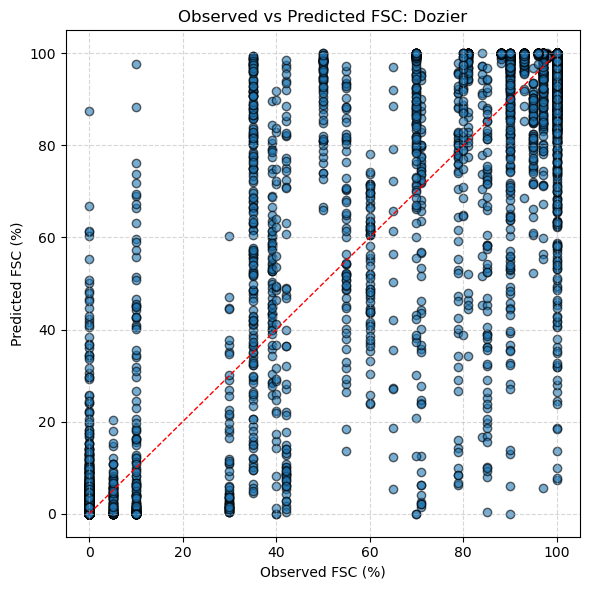

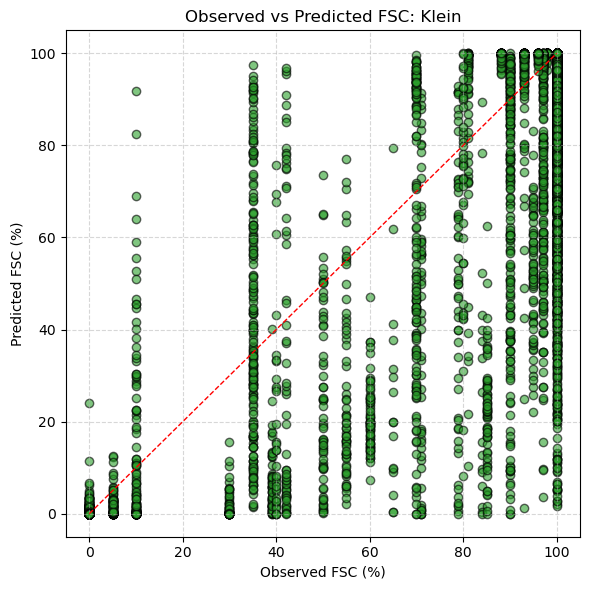

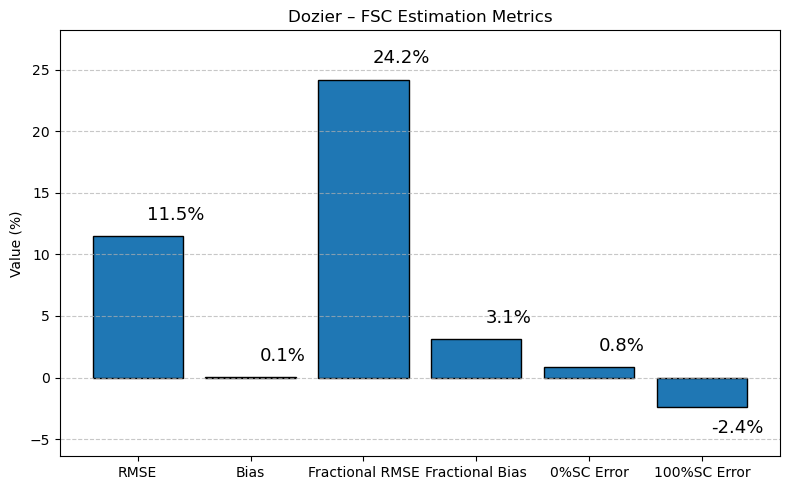

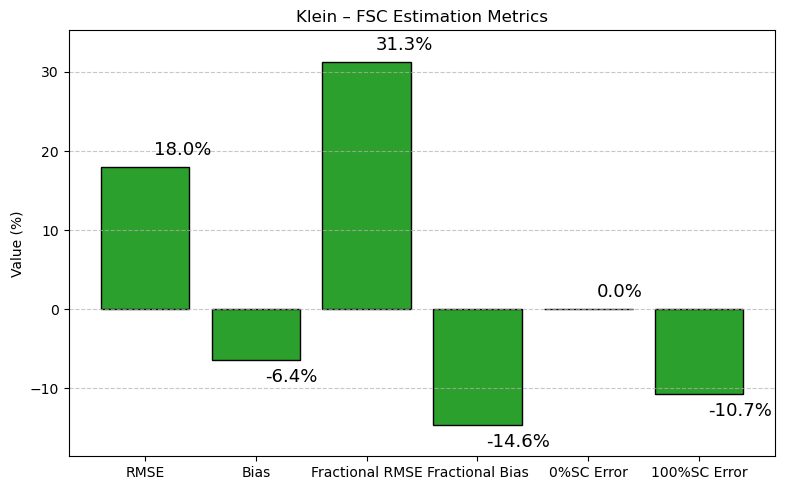

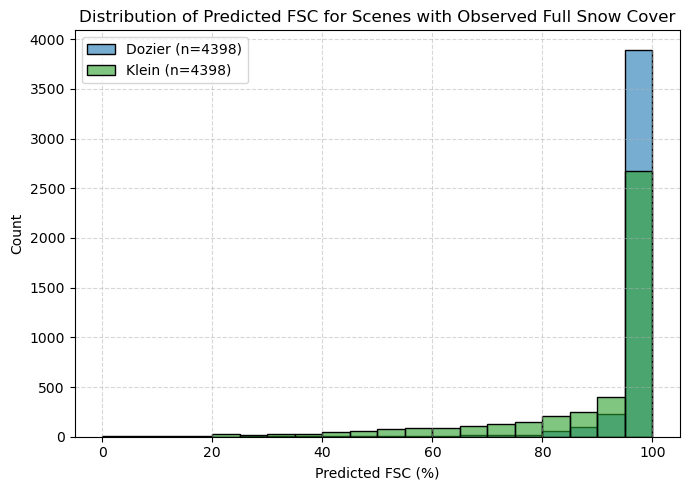

In [7]:
#80m

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

final_df = pd.read_pickle('landsat_aspect_results.pkl')

# final_df = pd.read_pickle('landsat_df_80m_0.2ff.pkl')
# final_df = final_df[final_df['cam']=='old_jack_pine']

# Melt the dataframe to long format for individual method plots
melted = final_df.melt(
    id_vars=["fsc", "filtered_fraction", "cam"],
    value_vars=["Dozier", "Klein"],  # , "Salomonson"
    var_name="method",
    value_name="predicted"
)

# Convert to percentages for plotting (0–100)
melted["fsc"] = melted["fsc"] * 100.0
melted["predicted"] = melted["predicted"] * 100.0

# Define color map (blue for Dozier, green for Klein)
method_colors = {
    "Dozier": "#1f77b4",
    "Klein": "#2ca02c",
    # "Salomonson": "#d62728"
}

# ---------- Scatter: Observed vs Predicted, one figure per method ----------
for method in ["Dozier", "Klein"]:  # , "Salomonson"
    subset = melted[melted["method"] == method]

    plt.figure(figsize=(6, 6))
    plt.scatter(
        subset["fsc"],
        subset["predicted"],
        alpha=0.6,
        edgecolor='k',
        c=method_colors[method],
        label=method
    )
    plt.plot([0, 100], [0, 100], 'r--', lw=1)
    plt.xlabel("Observed FSC (%)")
    plt.ylabel("Predicted FSC (%)")
    plt.title(f"Observed vs Predicted FSC: {method}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig(f'poster_landsat_{method}_actual_predicted.svg')
    plt.show()

# ---------- Metric helpers ----------
def rmse(y_true, y_pred):
    diff = y_pred - y_true
    return np.sqrt(np.nanmean(diff**2)) if np.isfinite(diff).any() else np.nan

def bias(y_true, y_pred):
    diff = y_pred - y_true
    return np.nanmean(diff) if np.isfinite(diff).any() else np.nan

def compute_all_metrics(df_method):
    """df_method: melted subset for a single method, with fsc/predicted in 0–100 units."""
    y = df_method["fsc"].to_numpy()
    yhat = df_method["predicted"].to_numpy()

    # Overall
    overall_rmse  = rmse(y, yhat)
    overall_bias  = bias(y, yhat)

    # Fractional (strictly between 0 and 100)
    frac_mask = (y > 0) & (y < 100)
    frac_rmse  = rmse(y[frac_mask], yhat[frac_mask])
    frac_bias  = bias(y[frac_mask], yhat[frac_mask])

    # Errors at the extremes
    zero_mask = (y == 0)
    full_mask = (y == 100)

    zero_bias = bias(y[zero_mask], yhat[zero_mask])   # "0%SC Error"
    full_bias = bias(y[full_mask], yhat[full_mask])   # "100%SC Error"

    metrics_order = ["RMSE", "Bias", "Fractional RMSE", "Fractional Bias", "0%SC Error", "100%SC Error"]
    values = np.array([
        overall_rmse,
        overall_bias,
        frac_rmse,
        frac_bias,
        zero_bias,
        full_bias
    ], dtype=float)

    return metrics_order, values

# ---------- Bar chart per method with six metrics ----------
for method in ["Dozier", "Klein"]:
    subset = melted[melted["method"] == method]
    metrics_labels, values = compute_all_metrics(subset)

    plt.figure(figsize=(8, 5))
    x = np.arange(len(metrics_labels))
    bars = plt.bar(x, values, edgecolor='black', color=method_colors[method])

    # Labels on bars (handle NaNs gracefully)
    for bar, val in zip(bars, values):
        height = 0 if np.isnan(val) else float(val)
        txt = "NaN" if np.isnan(val) else f"{height:.1f}%"
        x_offset = bar.get_x() + bar.get_width() * 0.6
        y_offset = 1 * np.sign(height if height != 0 else 1)
        plt.text(
            x_offset,
            height + y_offset,
            txt,
            ha='left',
            va='bottom' if height >= 0 else 'top',
            fontsize=13
        )

    plt.xticks(x, metrics_labels, rotation=0)
    plt.ylabel("Value (%)")
    plt.title(f"{method} – FSC Estimation Metrics")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Y-lims with padding, robust to NaNs
    finite_vals = values[np.isfinite(values)]
    if finite_vals.size == 0:
        ymin, ymax = -1, 1
    else:
        ymin = min(0.0, float(finite_vals.min())) - 4
        ymax = (float(finite_vals.max()) + 4) if float(finite_vals.max()) > 0 else 1
    plt.ylim(ymin, ymax)

    plt.tight_layout()
    # plt.savefig(f'poster_landsat_{method}_metrics.svg')
    plt.show()

# ---------- Histogram: Predicted FSC where observed FSC = 100% ----------

# Filter scenes where observed FSC is 100%
full_snow = melted[melted["fsc"] == 100].copy()

# Set up plot
plt.figure(figsize=(7, 5))
bins = np.linspace(0, 100, 21)  # 0–100 in 5% increments

for method in ["Dozier", "Klein"]:
# for method in ["Klein"]:
    subset = full_snow[full_snow["method"] == method]
    sns.histplot(
        subset["predicted"],
        bins=bins,
        kde=False,
        color=method_colors[method],
        label=f"{method} (n={len(subset)})",
        alpha=0.6,
        edgecolor="black"
    )

# Reference line at 100% (perfect prediction)
# plt.axvline(100, color="red", linestyle="--", linewidth=1, label="Observed = 100%")

plt.xlabel("Predicted FSC (%)")
plt.ylabel("Count")
plt.title("Distribution of Predicted FSC for Scenes with Observed Full Snow Cover")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("poster_landsat_full_snow_hist.svg")
plt.show()

In [3]:
final_df.columns

Index(['sampling_mode', 'grid_row', 'grid_col', 'grid_cell_id', 'sim_id',
       'beam_pair', 'anchor_beam_pair', 'anchor_edge', 'orientation',
       'offset_m', 'lat_bin', 'lat_bin_y_min', 'lat_bin_y_max', 'track_x0',
       'track_y0', 'track_x1', 'track_y1', 'box_center_lon', 'box_center_lat',
       'box_center_x', 'box_center_y', 'box_left', 'box_right', 'box_bottom',
       'box_top', 'pixel_count', 'valid_pixel_count', 'filtered_fraction',
       'north_facing_fraction', 'aspect_variability', 'gradient_p16',
       'gradient_p50', 'gradient_p84', 'topography_valid_pixel_count',
       'Dozier', 'Klein', 'Salomonson', 'fsc', 'cam', 'filepath',
       'landsat_scene_index'],
      dtype='object')

In [21]:
# Settings
ASPECT_VARIABILITY_THRESHOLD = 1.0
ASPECT_FACING_FRACTION_THRESHOLD = 0.75
GRADIENT_P84_THRESHOLD = 4.0


# South-facing fraction is the complement of north-facing fraction
south_facing_fraction = 1 - final_df["north_facing_fraction"]


# ============================================================
# DEFINE TOPOGRAPHY CATEGORIES
# ============================================================

north_cells = (
    final_df["aspect_variability"].le(ASPECT_VARIABILITY_THRESHOLD)
    &
    final_df["north_facing_fraction"].ge(ASPECT_FACING_FRACTION_THRESHOLD)
)

south_cells = (
    final_df["aspect_variability"].le(ASPECT_VARIABILITY_THRESHOLD)
    &
    south_facing_fraction.ge(ASPECT_FACING_FRACTION_THRESHOLD)
)

low_gradient_cells = final_df["gradient_p84"].lt(GRADIENT_P84_THRESHOLD)


# ============================================================
# DEFINE SNOW CONDITIONS
# ============================================================

no_snow = final_df["fsc"] == 0

full_snow = final_df["fsc"] == 1

partial_snow = (
    (final_df["fsc"] > 0)
    &
    (final_df["fsc"] < 1)
)


# ============================================================
# PRINT COUNTS
# ============================================================

categories = {
    "North-facing low variability": north_cells,
    "South-facing low variability": south_cells,
    "84th-percentile gradient < 5°": low_gradient_cells,
}


for name, mask in categories.items():

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Total:   {mask.sum()}")
    print(f"None:    {(mask & no_snow).sum()}")
    print(f"Partial: {(mask & partial_snow).sum()}")
    print(f"Full:    {(mask & full_snow).sum()}")


North-facing low variability
----------------------------
Total:   970
None:    382
Partial: 180
Full:    408

South-facing low variability
----------------------------
Total:   669
None:    248
Partial: 91
Full:    330

84th-percentile gradient < 5°
-----------------------------
Total:   1353
None:    653
Partial: 284
Full:    416


In [5]:
final_df.columns

Index(['sampling_mode', 'grid_row', 'grid_col', 'grid_cell_id', 'sim_id',
       'beam_pair', 'anchor_beam_pair', 'anchor_edge', 'orientation',
       'offset_m', 'lat_bin', 'lat_bin_y_min', 'lat_bin_y_max', 'track_x0',
       'track_y0', 'track_x1', 'track_y1', 'box_center_lon', 'box_center_lat',
       'box_center_x', 'box_center_y', 'box_left', 'box_right', 'box_bottom',
       'box_top', 'pixel_count', 'valid_pixel_count', 'filtered_fraction',
       'north_facing_fraction', 'aspect_variability', 'gradient_p16',
       'gradient_p50', 'gradient_p84', 'topography_valid_pixel_count',
       'Dozier', 'Klein', 'Salomonson', 'fsc', 'cam', 'filepath',
       'landsat_scene_index'],
      dtype='object')

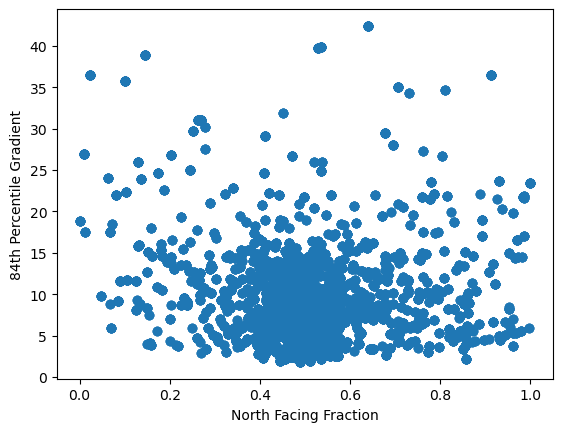

In [10]:
fig, ax = plt.subplots()

# sc = ax.scatter(
#     final_df.north_facing_fraction,
#     final_df.gradient_p50,
#     # c=final_df.gradient_p50
# )
sc = ax.scatter(
    final_df.north_facing_fraction,
    final_df.gradient_p84,
    # c=final_df.gradient_p50
)

ax.set_xlabel('North Facing Fraction')
ax.set_ylabel('84th Percentile Gradient')

# fig.colorbar(sc, ax=ax, label='Median Gradient (deg)')

plt.show()

In [2]:
fdf = final_df.copy()
# fdf = fdf[fdf['aspect_variability']<0.4]

Low aspect variability threshold: aspect_variability <= 1.0
Minimum north/south facing fraction: 0.75

Low aspect variability groups:
topography_group
north_dominated    970
south_dominated    669
Name: count, dtype: int64

Low-gradient threshold: gradient_p84 < 4.0°

Low-gradient group:
topography_group
low_gradient_p84    1353
Name: count, dtype: int64

Results for group: north_dominated
Number of rows: 970


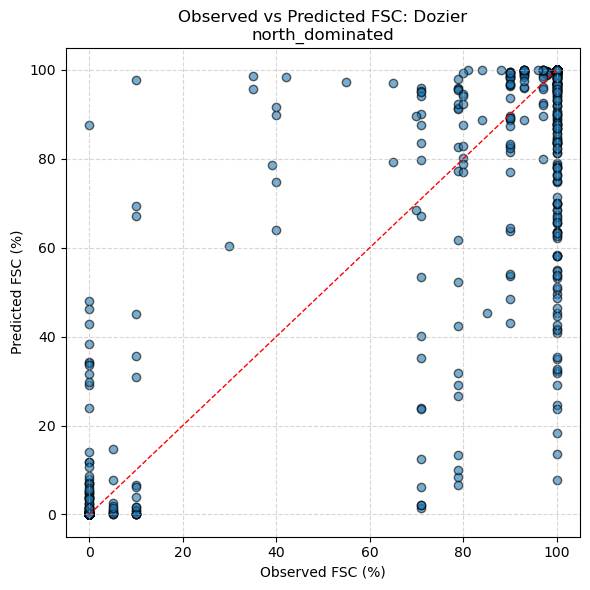

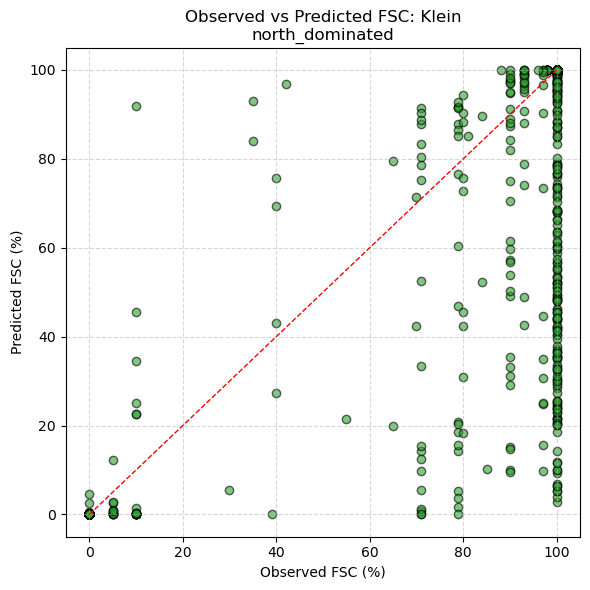

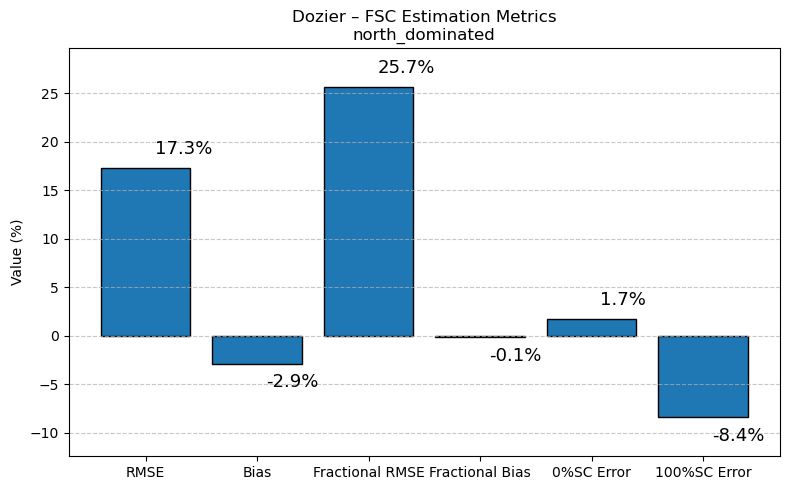

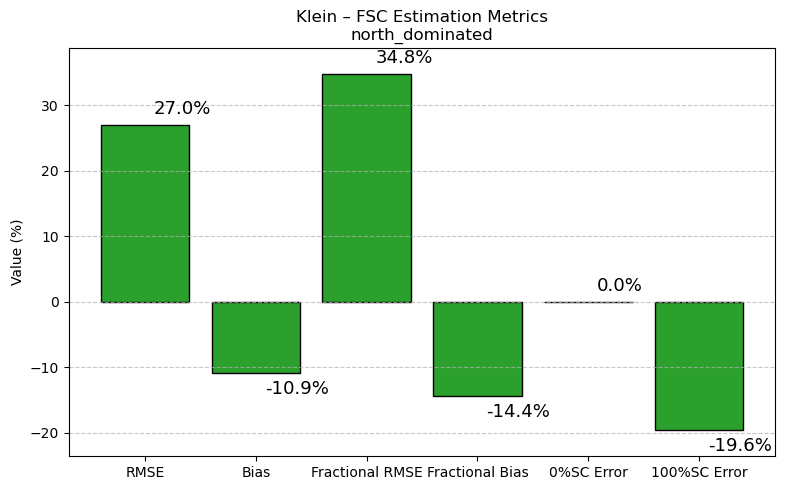


Metric summary:
   topography_group  method           metric      value
0   north_dominated  Dozier             RMSE  17.323770
1   north_dominated  Dozier             Bias  -2.902386
2   north_dominated  Dozier  Fractional RMSE  25.689940
3   north_dominated  Dozier  Fractional Bias  -0.144601
4   north_dominated  Dozier       0%SC Error   1.739032
5   north_dominated  Dozier     100%SC Error  -8.441944
6   north_dominated   Klein             RMSE  27.040510
7   north_dominated   Klein             Bias -10.948718
8   north_dominated   Klein  Fractional RMSE  34.828374
9   north_dominated   Klein  Fractional Bias -14.438157
10  north_dominated   Klein       0%SC Error   0.022158
11  north_dominated   Klein     100%SC Error -19.627232


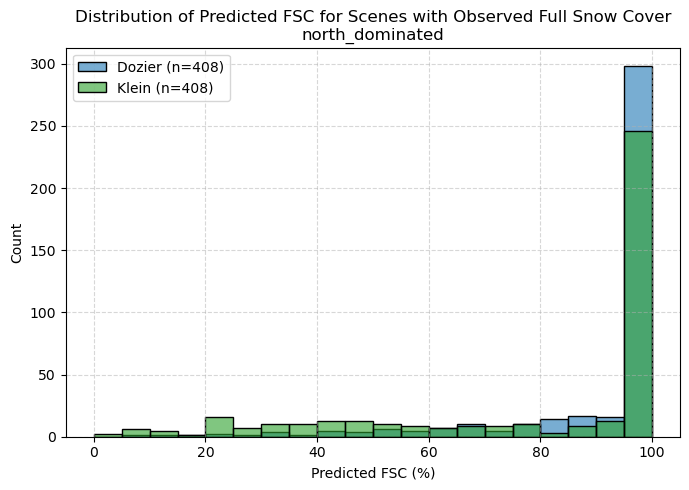


Results for group: south_dominated
Number of rows: 669


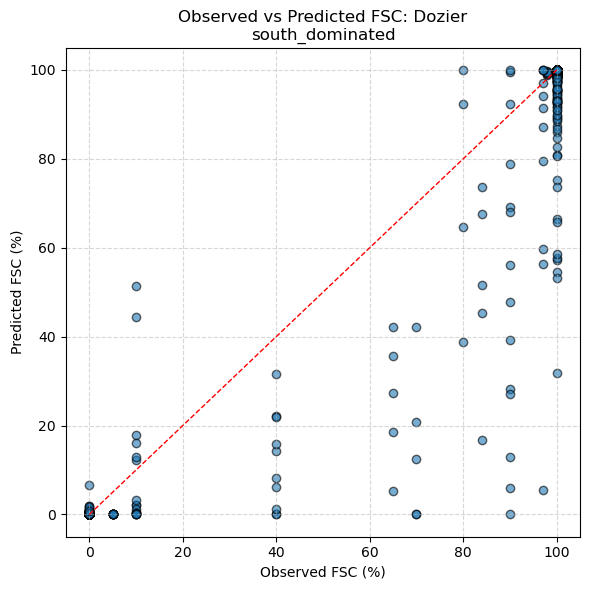

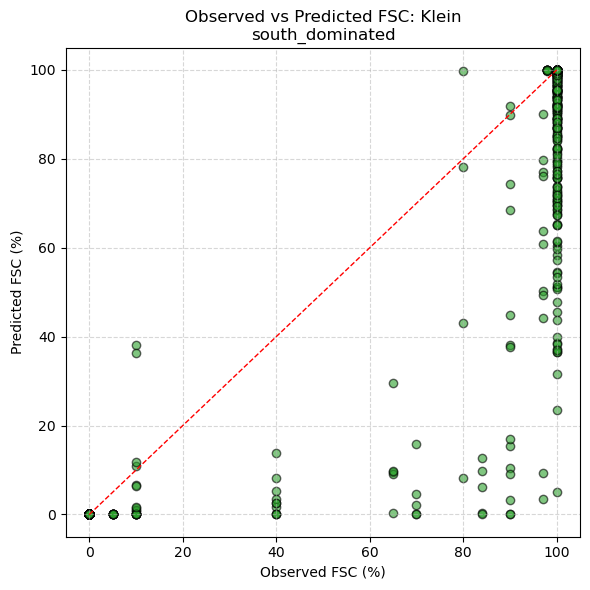

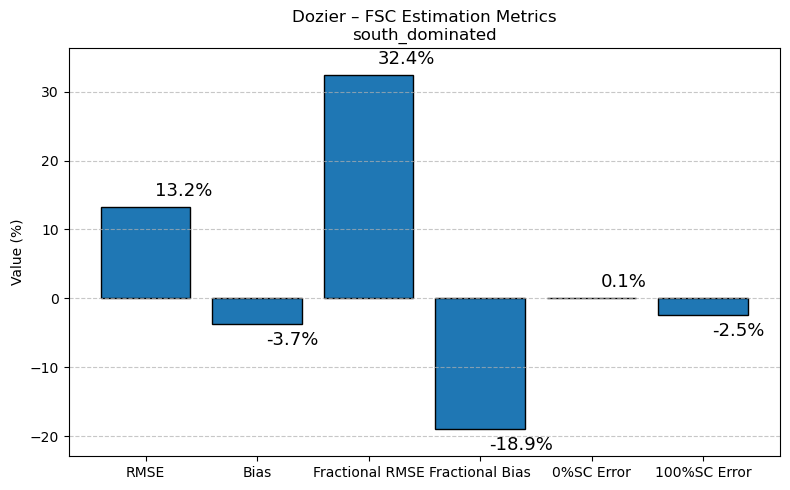

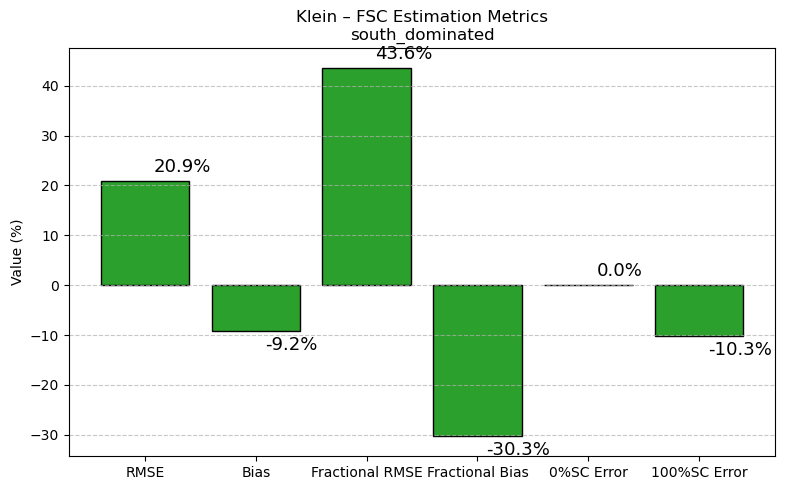


Metric summary:
   topography_group  method           metric      value
0   south_dominated  Dozier             RMSE  13.216936
1   south_dominated  Dozier             Bias  -3.744769
2   south_dominated  Dozier  Fractional RMSE  32.372978
3   south_dominated  Dozier  Fractional Bias -18.912698
4   south_dominated  Dozier       0%SC Error   0.112140
5   south_dominated  Dozier     100%SC Error  -2.460623
6   south_dominated   Klein             RMSE  20.943258
7   south_dominated   Klein             Bias  -9.189248
8   south_dominated   Klein  Fractional RMSE  43.602525
9   south_dominated   Klein  Fractional Bias -30.292915
10  south_dominated   Klein       0%SC Error   0.000000
11  south_dominated   Klein     100%SC Error -10.275610


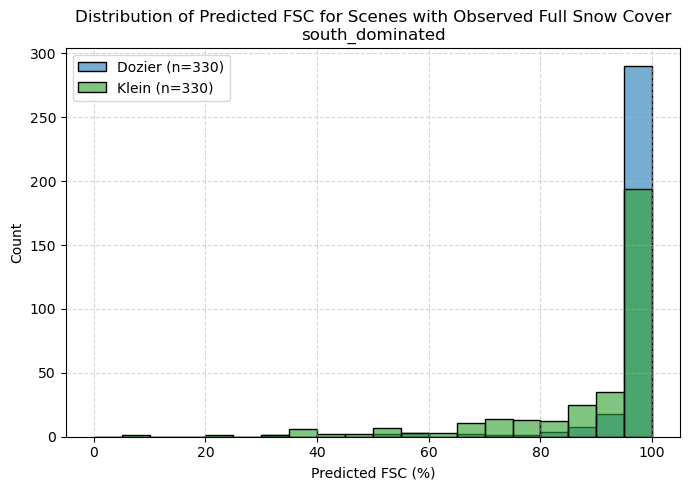


Results for group: low_gradient_p84
Number of rows: 1353


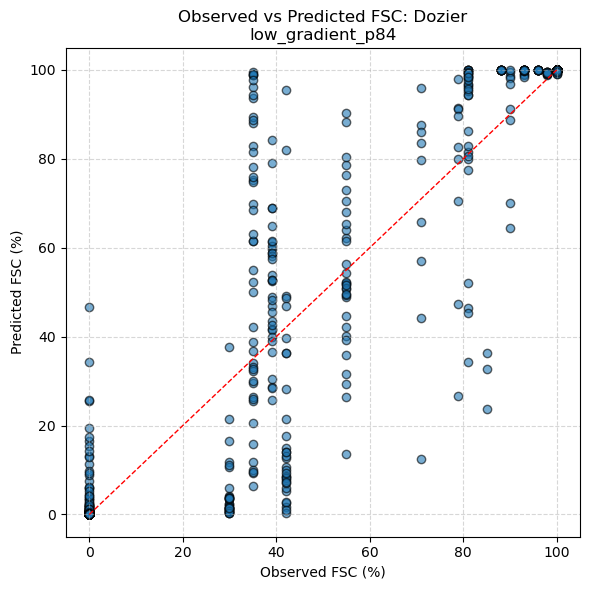

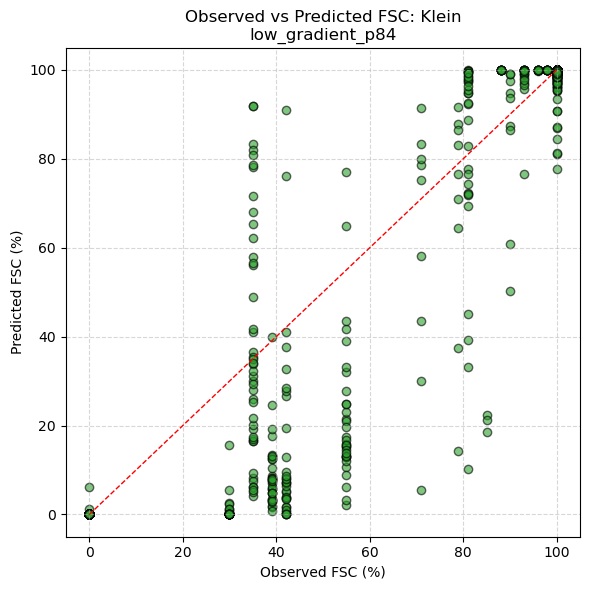

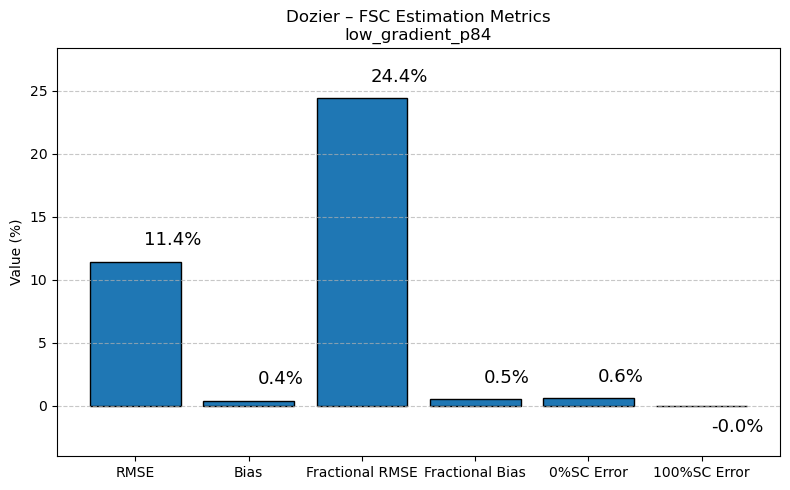

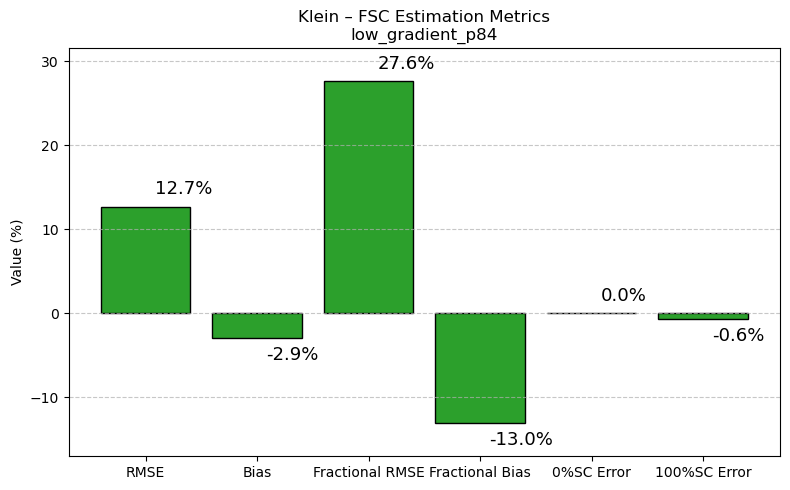


Metric summary:
    topography_group  method           metric      value
0   low_gradient_p84  Dozier             RMSE  11.418128
1   low_gradient_p84  Dozier             Bias   0.391993
2   low_gradient_p84  Dozier  Fractional RMSE  24.411116
3   low_gradient_p84  Dozier  Fractional Bias   0.524037
4   low_gradient_p84  Dozier       0%SC Error   0.591926
5   low_gradient_p84  Dozier     100%SC Error  -0.011989
6   low_gradient_p84   Klein             RMSE  12.726417
7   low_gradient_p84   Klein             Bias  -2.907118
8   low_gradient_p84   Klein  Fractional RMSE  27.630567
9   low_gradient_p84   Klein  Fractional Bias -12.997305
10  low_gradient_p84   Klein       0%SC Error   0.011250
11  low_gradient_p84   Klein     100%SC Error  -0.599621


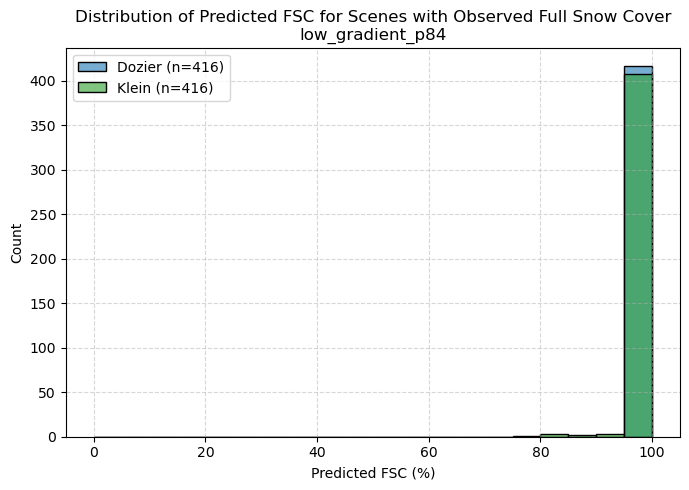


Combined topography-group metrics:
    topography_group  method           metric      value
0    north_dominated  Dozier             RMSE  17.323770
1    north_dominated  Dozier             Bias  -2.902386
2    north_dominated  Dozier  Fractional RMSE  25.689940
3    north_dominated  Dozier  Fractional Bias  -0.144601
4    north_dominated  Dozier       0%SC Error   1.739032
5    north_dominated  Dozier     100%SC Error  -8.441944
6    north_dominated   Klein             RMSE  27.040510
7    north_dominated   Klein             Bias -10.948718
8    north_dominated   Klein  Fractional RMSE  34.828374
9    north_dominated   Klein  Fractional Bias -14.438157
10   north_dominated   Klein       0%SC Error   0.022158
11   north_dominated   Klein     100%SC Error -19.627232
12   south_dominated  Dozier             RMSE  13.216936
13   south_dominated  Dozier             Bias  -3.744769
14   south_dominated  Dozier  Fractional RMSE  32.372978
15   south_dominated  Dozier  Fractional Bias -18.91

In [22]:
# 80m

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# ---------------------------------------------------------------------
# Analysis thresholds
# ---------------------------------------------------------------------
ASPECT_VARIABILITY_THRESHOLD = 1.0
ASPECT_FACING_FRACTION_THRESHOLD = 0.75
GRADIENT_P84_THRESHOLD = 4.0


if not (0.5 <= ASPECT_FACING_FRACTION_THRESHOLD <= 1.0):
    raise ValueError(
        "ASPECT_FACING_FRACTION_THRESHOLD must be between 0.5 and 1.0 inclusive."
    )


# ---------------------------------------------------------------------
# Create three analysis groups:
#
# 1. North-dominated cells with:
#       aspect_variability <= ASPECT_VARIABILITY_THRESHOLD
#       north_facing_fraction >= ASPECT_FACING_FRACTION_THRESHOLD
#
# 2. South-dominated cells with:
#       aspect_variability <= ASPECT_VARIABILITY_THRESHOLD
#       south_facing_fraction >= ASPECT_FACING_FRACTION_THRESHOLD
#
# 3. Low-gradient cells with:
#       gradient_p84 < GRADIENT_P84_THRESHOLD
#       aspect direction ignored
# ---------------------------------------------------------------------

# Low aspect variability dataframe for north/south comparison
fdf_aspect = final_df[
    final_df["aspect_variability"] <= ASPECT_VARIABILITY_THRESHOLD
].copy()

fdf_aspect["topography_group"] = pd.NA


# North-facing cells
fdf_aspect.loc[
    fdf_aspect["north_facing_fraction"]
    >= ASPECT_FACING_FRACTION_THRESHOLD,
    "topography_group"
] = "north_dominated"


# South-facing cells
fdf_aspect.loc[
    fdf_aspect["north_facing_fraction"]
    <= 1 - ASPECT_FACING_FRACTION_THRESHOLD,
    "topography_group"
] = "south_dominated"


# Drop cells that do not meet either facing-fraction threshold
fdf_aspect = fdf_aspect.dropna(
    subset=["topography_group"]
).copy()


# ---------------------------------------------------------------------
# Low-gradient dataframe
# No north/south classification is considered here
# ---------------------------------------------------------------------
fdf_low_gradient = final_df[
    final_df["gradient_p84"] < GRADIENT_P84_THRESHOLD
].copy()

fdf_low_gradient["topography_group"] = "low_gradient_p84"


# ---------------------------------------------------------------------
# Print group information
# ---------------------------------------------------------------------
print(
    f"Low aspect variability threshold: "
    f"aspect_variability <= {ASPECT_VARIABILITY_THRESHOLD}"
)

print(
    f"Minimum north/south facing fraction: "
    f"{ASPECT_FACING_FRACTION_THRESHOLD}"
)

print("\nLow aspect variability groups:")
print(
    fdf_aspect["topography_group"].value_counts()
)

print(
    f"\nLow-gradient threshold: "
    f"gradient_p84 < {GRADIENT_P84_THRESHOLD}°"
)

print("\nLow-gradient group:")
print(
    fdf_low_gradient["topography_group"].value_counts()
)


# ---------------------------------------------------------------------
# Metric helpers
# ---------------------------------------------------------------------
def rmse(y_true, y_pred):

    diff = y_pred - y_true

    return (
        np.sqrt(np.nanmean(diff**2))
        if np.isfinite(diff).any()
        else np.nan
    )


def bias(y_true, y_pred):

    diff = y_pred - y_true

    return (
        np.nanmean(diff)
        if np.isfinite(diff).any()
        else np.nan
    )


def compute_all_metrics(df_method):
    """
    df_method: melted subset for a single method, with fsc/predicted
    in 0–100 units.
    """

    y = df_method["fsc"].to_numpy()
    yhat = df_method["predicted"].to_numpy()


    # Overall
    overall_rmse = rmse(y, yhat)
    overall_bias = bias(y, yhat)


    # Fractional, strictly between 0 and 100
    frac_mask = (
        (y > 0)
        &
        (y < 100)
    )

    frac_rmse = rmse(
        y[frac_mask],
        yhat[frac_mask]
    )

    frac_bias = bias(
        y[frac_mask],
        yhat[frac_mask]
    )


    # Errors at the extremes
    zero_mask = y == 0
    full_mask = y == 100

    zero_bias = bias(
        y[zero_mask],
        yhat[zero_mask]
    )

    full_bias = bias(
        y[full_mask],
        yhat[full_mask]
    )


    metrics_order = [
        "RMSE",
        "Bias",
        "Fractional RMSE",
        "Fractional Bias",
        "0%SC Error",
        "100%SC Error",
    ]

    values = np.array(
        [
            overall_rmse,
            overall_bias,
            frac_rmse,
            frac_bias,
            zero_bias,
            full_bias,
        ],
        dtype=float
    )

    return metrics_order, values


# ---------------------------------------------------------------------
# Plotting/analysis function for one group
# ---------------------------------------------------------------------
def run_fsc_analysis_for_topography_group(
    df_group,
    topography_group_name
):
    """
    Run the FSC plots and metric summaries for one topographic group.
    """

    print("\n" + "=" * 80)
    print(f"Results for group: {topography_group_name}")
    print(f"Number of rows: {len(df_group)}")
    print("=" * 80)


    # Melt the dataframe to long format for individual method plots
    melted = df_group.melt(
        id_vars=[
            "fsc",
            "filtered_fraction",
            "cam",
            "north_facing_fraction",
            "aspect_variability",
            "gradient_p84",
            "topography_group",
        ],
        value_vars=[
            "Dozier",
            "Klein",
        ],
        var_name="method",
        value_name="predicted",
    )


    # Convert to percentages for plotting, 0–100
    melted["fsc"] = melted["fsc"] * 100.0
    melted["predicted"] = melted["predicted"] * 100.0


    method_colors = {
        "Dozier": "#1f77b4",
        "Klein": "#2ca02c",
    }


    # -----------------------------------------------------------------
    # Scatter: observed vs predicted, one figure per method
    # -----------------------------------------------------------------
    for method in ["Dozier", "Klein"]:

        subset = melted[
            melted["method"] == method
        ]

        plt.figure(figsize=(6, 6))

        plt.scatter(
            subset["fsc"],
            subset["predicted"],
            alpha=0.6,
            edgecolor="k",
            c=method_colors[method],
            label=method,
        )

        plt.plot(
            [0, 100],
            [0, 100],
            "r--",
            lw=1,
        )

        plt.xlabel("Observed FSC (%)")
        plt.ylabel("Predicted FSC (%)")

        plt.title(
            f"Observed vs Predicted FSC: {method}\n"
            f"{topography_group_name}"
        )

        plt.grid(
            True,
            linestyle="--",
            alpha=0.5,
        )

        plt.tight_layout()

        # plt.savefig(
        #     f"poster_landsat_{topography_group_name}_"
        #     f"{method}_actual_predicted.svg"
        # )

        plt.show()


    # -----------------------------------------------------------------
    # Bar chart per method with six metrics
    # -----------------------------------------------------------------
    all_metric_rows = []

    for method in ["Dozier", "Klein"]:

        subset = melted[
            melted["method"] == method
        ]

        metrics_labels, values = compute_all_metrics(
            subset
        )

        for label, value in zip(
            metrics_labels,
            values
        ):

            all_metric_rows.append({
                "topography_group": topography_group_name,
                "method": method,
                "metric": label,
                "value": value,
            })


        plt.figure(figsize=(8, 5))

        x = np.arange(
            len(metrics_labels)
        )

        bars = plt.bar(
            x,
            values,
            edgecolor="black",
            color=method_colors[method],
        )


        # Labels on bars, handling NaNs
        for bar, val in zip(bars, values):

            height = (
                0
                if np.isnan(val)
                else float(val)
            )

            txt = (
                "NaN"
                if np.isnan(val)
                else f"{height:.1f}%"
            )

            x_offset = (
                bar.get_x()
                +
                bar.get_width() * 0.6
            )

            y_offset = np.sign(
                height if height != 0 else 1
            )

            plt.text(
                x_offset,
                height + y_offset,
                txt,
                ha="left",
                va=(
                    "bottom"
                    if height >= 0
                    else "top"
                ),
                fontsize=13,
            )


        plt.xticks(
            x,
            metrics_labels,
            rotation=0,
        )

        plt.ylabel("Value (%)")

        plt.title(
            f"{method} – FSC Estimation Metrics\n"
            f"{topography_group_name}"
        )

        plt.grid(
            axis="y",
            linestyle="--",
            alpha=0.7,
        )


        # Y-limits with padding, robust to NaNs
        finite_vals = values[
            np.isfinite(values)
        ]

        if finite_vals.size == 0:

            ymin, ymax = -1, 1

        else:

            ymin = (
                min(
                    0.0,
                    float(finite_vals.min())
                )
                - 4
            )

            maximum_value = float(
                finite_vals.max()
            )

            ymax = (
                maximum_value + 4
                if maximum_value > 0
                else 1
            )

        plt.ylim(
            ymin,
            ymax
        )

        plt.tight_layout()

        # plt.savefig(
        #     f"poster_landsat_{topography_group_name}_"
        #     f"{method}_metrics.svg"
        # )

        plt.show()


    metrics_df = pd.DataFrame(
        all_metric_rows
    )

    print("\nMetric summary:")
    print(metrics_df)


    # -----------------------------------------------------------------
    # Histogram: predicted FSC where observed FSC = 100%
    # -----------------------------------------------------------------
    full_snow = melted[
        melted["fsc"] == 100
    ].copy()

    plt.figure(figsize=(7, 5))

    bins = np.linspace(
        0,
        100,
        21
    )


    for method in ["Dozier", "Klein"]:

        subset = full_snow[
            full_snow["method"] == method
        ]

        sns.histplot(
            subset["predicted"],
            bins=bins,
            kde=False,
            color=method_colors[method],
            label=f"{method} (n={len(subset)})",
            alpha=0.6,
            edgecolor="black",
        )


    plt.xlabel("Predicted FSC (%)")
    plt.ylabel("Count")

    plt.title(
        "Distribution of Predicted FSC for Scenes "
        "with Observed Full Snow Cover\n"
        f"{topography_group_name}"
    )

    plt.legend()

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5,
    )

    plt.tight_layout()

    # plt.savefig(
    #     f"poster_landsat_{topography_group_name}_"
    #     f"full_snow_hist.svg"
    # )

    plt.show()

    return metrics_df


# ---------------------------------------------------------------------
# Run analysis for:
#
# 1. North-dominated low-aspect-variability cells
# 2. South-dominated low-aspect-variability cells
# 3. Cells with gradient_p84 < GRADIENT_P84_THRESHOLD
# ---------------------------------------------------------------------
all_metrics = []


# North- and south-dominated groups
for (
    topography_group_name,
    df_group
) in fdf_aspect.groupby(
    "topography_group"
):

    metrics_df = run_fsc_analysis_for_topography_group(
        df_group=df_group,
        topography_group_name=topography_group_name,
    )

    all_metrics.append(
        metrics_df
    )


# Low-gradient group
if not fdf_low_gradient.empty:

    metrics_df = run_fsc_analysis_for_topography_group(
        df_group=fdf_low_gradient,
        topography_group_name="low_gradient_p84",
    )

    all_metrics.append(
        metrics_df
    )

else:

    print(
        f"\nNo cells found with "
        f"gradient_p84 < {GRADIENT_P84_THRESHOLD}°."
    )


# ---------------------------------------------------------------------
# Combine all results
# ---------------------------------------------------------------------
if all_metrics:

    topography_metrics_df = pd.concat(
        all_metrics,
        ignore_index=True,
    )

else:

    topography_metrics_df = pd.DataFrame()


print("\nCombined topography-group metrics:")
print(topography_metrics_df)

               cam  method       RMSE       Bias  Fractional RMSE  \
0         bartlett  Dozier  13.586205  -5.217869         4.872099   
1         bartlett   Klein  24.942261 -13.468992         4.842188   
2   delta_junction  Dozier  15.738856  -3.093508        26.082893   
3   delta_junction   Klein  21.748066  -7.943565        36.054587   
4            glees  Dozier   7.840164   0.458636        34.921735   
5            glees   Klein  17.041197  -6.141285        27.885784   
6         hyytiala  Dozier   5.921860  -2.194299        12.437017   
7         hyytiala   Klein  21.578118 -11.552141        41.675592   
8       kenttarova  Dozier   1.730773   0.025580         1.478082   
9       kenttarova   Klein   1.757761  -0.095032         1.931629   
10        lacclair  Dozier  10.322806  -1.668166        22.012489   
11        lacclair   Klein  15.745147  -6.137401        31.497109   
12         marcell  Dozier  11.747728   4.412785        24.515747   
13         marcell   Klein  12.451

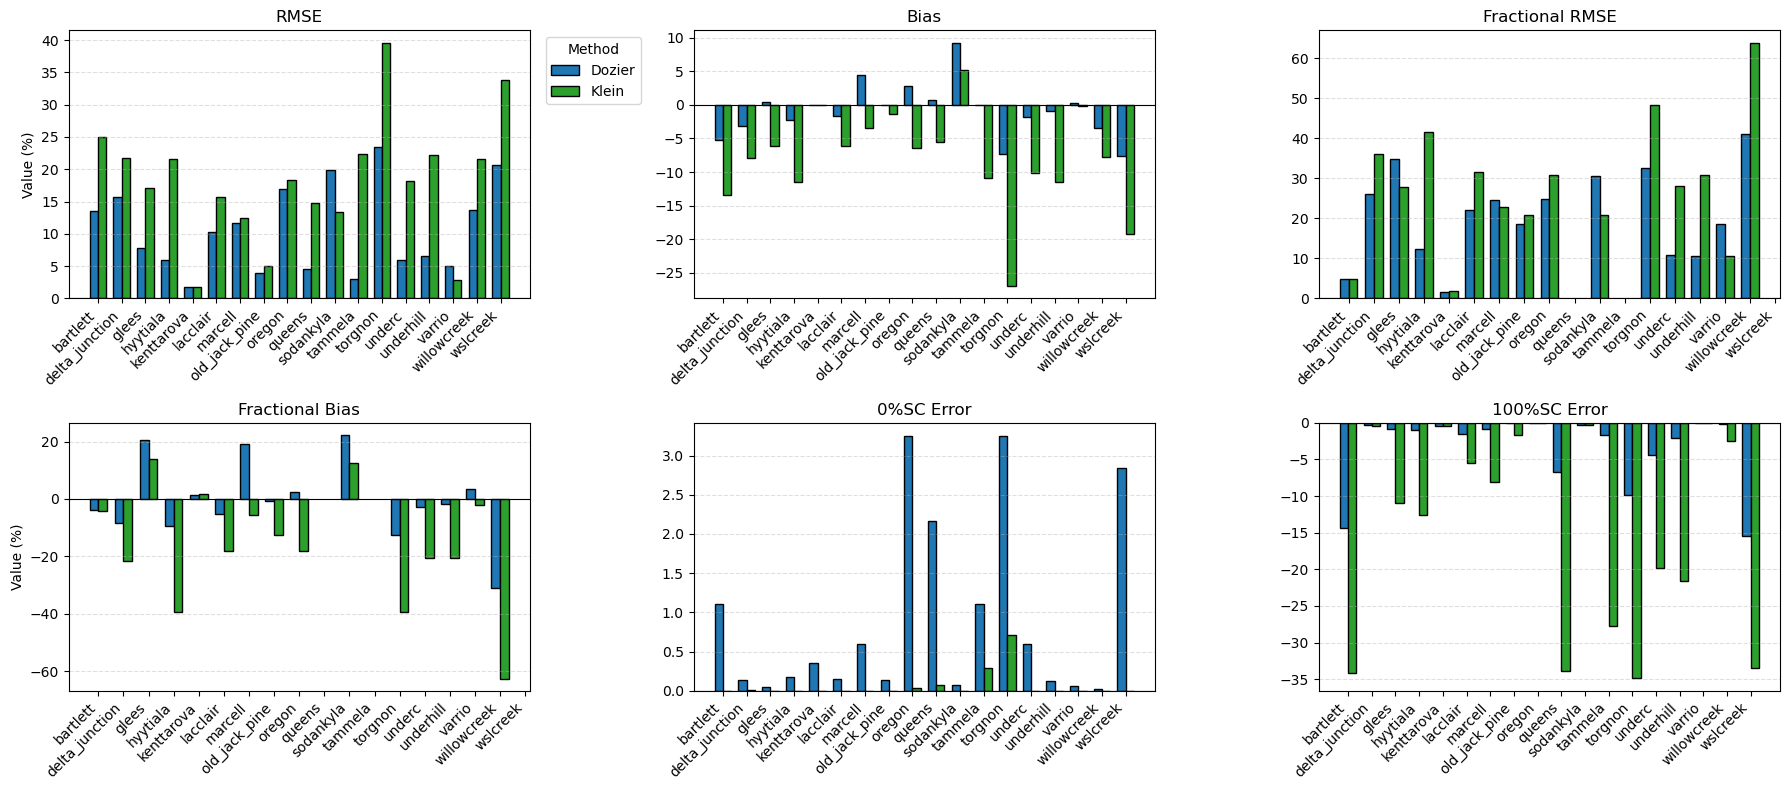

In [6]:
# per-camera metrics for klein and dozier

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------
# Load / prepare data as before
# ---------------------------------
# final_df = pd.read_pickle('landsat_df_80m_0.2ff.pkl')

# Melt the dataframe to long format for individual method plots
melted = final_df.melt(
    id_vars=["fsc", "filtered_fraction", "cam"],
    value_vars=["Dozier", "Klein"],  # , "Salomonson"
    var_name="method",
    value_name="predicted"
)

# Convert to percentages for plotting (0–100)
melted["fsc"] = melted["fsc"] * 100.0
melted["predicted"] = melted["predicted"] * 100.0

# Define color map (blue for Dozier, green for Klein)
method_colors = {
    "Dozier": "#1f77b4",
    "Klein": "#2ca02c",
    # "Salomonson": "#d62728"
}

methods = ["Dozier", "Klein"]

# ---------------------------------
# Metric helpers (unchanged)
# ---------------------------------
def rmse(y_true, y_pred):
    diff = y_pred - y_true
    return np.sqrt(np.nanmean(diff**2)) if np.isfinite(diff).any() else np.nan

def bias(y_true, y_pred):
    diff = y_pred - y_true
    return np.nanmean(diff) if np.isfinite(diff).any() else np.nan

def compute_all_metrics(df_method):
    """
    df_method: melted subset for a single method & camera,
               with fsc/predicted in 0–100 units.
    """
    y = df_method["fsc"].to_numpy()
    yhat = df_method["predicted"].to_numpy()

    # Overall
    overall_rmse  = rmse(y, yhat)
    overall_bias  = bias(y, yhat)

    # Fractional (strictly between 0 and 100)
    frac_mask = (y > 0) & (y < 100)
    frac_rmse  = rmse(y[frac_mask], yhat[frac_mask])
    frac_bias  = bias(y[frac_mask], yhat[frac_mask])

    # Errors at the extremes
    zero_mask = (y == 0)
    full_mask = (y == 100)

    zero_bias = bias(y[zero_mask], yhat[zero_mask])   # "0%SC Error"
    full_bias = bias(y[full_mask], yhat[full_mask])   # "100%SC Error"

    metrics_order = ["RMSE", "Bias", "Fractional RMSE", "Fractional Bias",
                     "0%SC Error", "100%SC Error"]
    values = np.array([
        overall_rmse,
        overall_bias,
        frac_rmse,
        frac_bias,
        zero_bias,
        full_bias
    ], dtype=float)

    return metrics_order, values

# ---------------------------------
# NEW: compute metrics per camera & method
# ---------------------------------
records = []
metrics_order_global = None

grouped = melted.groupby(["cam", "method"])

for (cam, method), df_sub in grouped:
    metrics_labels, values = compute_all_metrics(df_sub)

    if metrics_order_global is None:
        metrics_order_global = metrics_labels  # keep consistent order

    rec = {"cam": cam, "method": method}
    rec.update({label: val for label, val in zip(metrics_labels, values)})
    records.append(rec)

metrics_df = pd.DataFrame.from_records(records)

# Optional: look at the table in the console
print(metrics_df)

# ---------------------------------
# NEW: single figure with 6 subplots (one per metric)
# ---------------------------------
cams = sorted(metrics_df["cam"].unique())
n_cams = len(cams)
n_methods = len(methods)

x = np.arange(n_cams)
bar_width = 0.35 if n_methods == 2 else 0.8 / n_methods

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=False)
axes = axes.ravel()

for idx, metric in enumerate(metrics_order_global):
    ax = axes[idx]

    for j, method in enumerate(methods):
        # Ensure consistent cam order
        sub = (metrics_df[metrics_df["method"] == method]
               .set_index("cam")
               .reindex(cams))

        vals = sub[metric].to_numpy()

        # centre the bars for multiple methods
        offset = (j - (n_methods - 1) / 2) * bar_width
        ax.bar(
            x + offset,
            vals,
            width=bar_width,
            color=method_colors.get(method, None),
            edgecolor="black",
            label=method if idx == 0 else None
        )

    ax.set_title(metric)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(cams, rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    if idx in (0, 3):  # left column
        ax.set_ylabel("Value (%)")

# Put the legend only once
if n_methods > 1:
    axes[0].legend(title="Method", bbox_to_anchor=(1.02, 1.0), loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:
Per-site OOB metrics across all bootstraps, values in %:
        camera  n_oob_predictions  n_oob_0  n_oob_1  n_oob_partial      RMSE       Bias  Fractional RMSE  Fractional Bias  0%SC Error  100%SC Error
      bartlett               6376     1636     3228           1512 40.842825 -23.082608        72.909235       -71.777732    0.000000    -11.972360
delta_junction              25169     9601     8205           7363 17.792171   0.029856        32.884152         0.043003    0.045289      0.000000
         glees              13016     4017     8999              0  9.670686   1.219342              NaN              NaN    6.676770     -1.216760
      hyytiala              28797    25035     3637            125  6.287877  -0.405992         1.000000        -1.000000    0.677864     -7.846208
    kenttarova              21535     7477     9281           4777  3.964110   0.684203         4.506042         3.677798    0.263484     -0.517681
      lacclair              10976      327     8359           2290 11.306171  -3.840030        24.621526       -18.031922    0.000000     -0.102294
    marcell_MN              13593     5469     7643            481  8.258219  -1.788710        38.303089       -27.568800    0.058980     -1.488409
 old_jack_pine              36143    21451     9391           5301 16.804509   1.190542        36.046879        -0.376685    2.216960     -0.269346
     oregon_yp              43734    39968        0           3766 13.908334   5.569471        25.226319       -20.963746    8.069573           NaN
        queens               2896     1057     1839              0  3.076889   0.273561              NaN              NaN    0.749511      0.000000
sodankyla_full              36573    19390    16841            342  5.830639   0.714659        14.588015        -9.906016    1.626504     -0.119520
       tammela              19411    14845     4566              0  1.139682  -0.103426              NaN              NaN    0.005788     -0.458505
       torgnon               1097      224      873              0  8.215479   2.525294              NaN              NaN   12.367175      0.000000
        underc              18241     6398     8295           3548 13.642332  -0.361681        26.971754        -7.314769    3.049519     -0.018739
     underhill               2939     1229     1710              0 30.714154  10.905223              NaN              NaN   26.078648     -0.000121
        varrio              21506     5467    16039              0  0.000000   0.000000              NaN              NaN    0.000000      0.000000
   willowcreek              15494     9507     5987              0 32.369826   2.395107              NaN              NaN   14.359939    -16.604333
      wslcreek               9527      771     7729           1027  6.404962   1.339762        18.238286         9.782197    3.544533     -0.001972

OOB metrics mean +/- std across bootstraps, ignoring NaNs:
RMSE:       0.1395 +/- 0.0365
Bias:       0.0044 +/- 0.0183
Frac RMSE:  0.3034 +/- 0.0911
Frac Bias:  -0.0991 +/- 0.1112
0%SC Bias:  0.0340 +/- 0.0245
100%SC Bias:  -0.0180 +/- 0.0178

OOB metrics by aspect group, mean +/- std across bootstraps using rows where aspect_variability <= 1.0 and with north/south facing fraction threshold = 0.75:

north_dominated:
Rows:         30140
RMSE:         0.1624 +/- 0.1209
Bias:         -0.0340 +/- 0.0761
Frac RMSE:    0.3354 +/- 0.1952
Frac Bias:    -0.1317 +/- 0.2452
0%SC Bias:    0.0148 +/- 0.0458
100%SC Bias:  -0.0197 +/- 0.0463

south_dominated:
Rows:         11299
RMSE:         0.0423 +/- 0.0918
Bias:         -0.0082 +/- 0.0409
Frac RMSE:    0.2059 +/- 0.3018
Frac Bias:    -0.1258 +/- 0.3191
0%SC Bias:    0.0057 +/- 0.0142
100%SC Bias:  -0.0001 +/- 0.0013

OOB metrics for high aspect variability, mean +/- std across bootstraps using rows where aspect_variability > 0.8.
North/south aspect dominance is not considered.

high_aspect_variability:
Rows:         172967
RMSE:         0.1307 +/- 0.0494
Bias:         0.0168 +/- 0.0362
Frac RMSE:    0.2257 +/- 0.0704
Frac Bias:    -0.1080 +/- 0.0729
0%SC Bias:    0.0521 +/- 0.0452
100%SC Bias:  -0.0238 +/- 0.0514

CV metrics mean +/- std across chosen filters per bootstrap:
Multiclass accuracy:  0.9257 +/- 0.0352
Binary accuracy 0 vs {1,2}:  0.9734 +/- 0.0222
Total Cells: 327023
Total Non-Snow Cells: 173869
Total Snow Cells: 122622
Total Partial Snow Cells: 30532

In [8]:
from scripts.imports import *

import numpy as np
import pandas as pd
import rioxarray

from pathlib import Path
from rasterio.enums import Resampling
from pyproj import Transformer


# ============================================================
# SETTINGS
# ============================================================

E = 80

# Low aspect variability threshold:
ASPECT_VARIABILITY_THRESHOLD = 1.0

# Fraction of valid aspect pixels required to classify a cell
# as north- or south-facing.
ASPECT_FACING_FRACTION_THRESHOLD = 0.75

# High aspect variability threshold:
HIGH_ASPECT_VARIABILITY_THRESHOLD = 0.8


MASKING_FOLDER = Path("../scratch/data/landsat_masking/")

FOREST_LANDCOVER_MIN = 111
FOREST_LANDCOVER_MAX = 126

CELL_SIZE_M = 1000
HALF_CELL_M = CELL_SIZE_M / 2

ELEVATION_TOLERANCE_M = E

LAT_COL = "lat"
LON_COL = "lon"
ALT_COL = "altitude"
CAM_COL = "camera"


CAM_FILE_CANDIDATES = {
    "sodankyla_full": ["sodankyla_full", "sodankyla"],
    "sodankyla": ["sodankyla", "sodankyla_full"],
    "marcell_MN": ["marcell_MN", "marcell"],
    "marcell": ["marcell", "marcell_MN"],
    "oregon_yp": ["oregon_yp", "oregon"],
    "oregon": ["oregon", "oregon_yp"],
}


# ============================================================
# LOAD AND GROUP DATA
# ============================================================

df = pd.read_pickle(
    f"dataset_lcforest_noLOF_bin15_th3_"
    f"{E}m_1kmsmallbox_noprior_ta_wc1_v7.pkl"
)


df["Eg_strong"] = np.where(
    (df["beam_str"] == "strong") &
    (df["outlier"] == 1),
    df["Eg"],
    np.nan
)


# Keep FSC and TreeSnow so snow condition can be reconstructed
# after grouping.
agg_dict = {
    "Eg_strong": "median",
    "altitude": "median",
    "FSC": "mean",
    "TreeSnow": "mean",
}


df_grouped = (
    df
    .groupby(
        [
            "camera",
            "date",
            "lat",
            "lon",
        ]
    )
    .agg(agg_dict)
    .reset_index()
)


df_grouped = (
    df_grouped[
        df_grouped["Eg_strong"] >= 0
    ]
    .copy()
    .reset_index(drop=True)
)


# Same snow definition used in your bootstrap script
df_grouped["JointSnow"] = (
    df_grouped["FSC"]
    +
    df_grouped["TreeSnow"]
)

df_grouped["JointSnowBinary"] = (
    df_grouped["JointSnow"]
    .apply(
        lambda x: 1
        if x >= 1
        else x
    )
    .astype(float)
)


print(f"Total grouped cells: {len(df_grouped)}")


# ============================================================
# TOPOGRAPHY HELPERS
# ============================================================

def local_utm_crs(lon, lat):

    zone = int((lon + 180) // 6) + 1

    epsg = (
        32600 + zone
        if lat >= 0
        else 32700 + zone
    )

    return f"EPSG:{epsg}"


def find_topography_files(masking_folder, cam):

    landcover_fp = None
    elevation_fp = None
    gradient_fp = None
    aspect_fp = None

    cam_candidates = CAM_FILE_CANDIDATES.get(
        str(cam),
        [str(cam)]
    )

    cam_candidates = [
        c.lower()
        for c in cam_candidates
    ]

    for fp in masking_folder.glob("*.tif"):

        name_lower = fp.name.lower()

        if not any(
            c in name_lower
            for c in cam_candidates
        ):
            continue

        if "landcover" in name_lower:
            landcover_fp = fp

        elif "alos_aw3d30_elevation" in name_lower:
            elevation_fp = fp

        elif "alos_aw3d30_gradient" in name_lower:
            gradient_fp = fp

        elif "alos_aw3d30_aspect" in name_lower:
            aspect_fp = fp

    return (
        landcover_fp,
        elevation_fp,
        gradient_fp,
        aspect_fp,
    )


def add_topography_to_grouped_df(df_grouped):

    df_grouped = df_grouped.copy()

    df_grouped["north_facing_fraction"] = np.nan
    df_grouped["south_facing_fraction"] = np.nan
    df_grouped["aspect_variability"] = np.nan
    df_grouped["topography_valid_pixel_count"] = 0


    for cam, cam_df in df_grouped.groupby(CAM_COL):

        print(f"\nProcessing {cam}: {len(cam_df)} cells")

        (
            landcover_fp,
            elevation_fp,
            gradient_fp,
            aspect_fp,
        ) = find_topography_files(
            MASKING_FOLDER,
            cam
        )


        if any(
            x is None
            for x in [
                landcover_fp,
                elevation_fp,
                aspect_fp,
            ]
        ):

            print(f"  Skipping {cam}: missing raster(s)")
            print(f"    landcover: {landcover_fp}")
            print(f"    elevation: {elevation_fp}")
            print(f"    aspect:    {aspect_fp}")

            continue


        elevation_raw = (
            rioxarray
            .open_rasterio(
                elevation_fp,
                masked=True
            )
            .squeeze()
        )


        landcover_raw = (
            rioxarray
            .open_rasterio(
                landcover_fp,
                masked=True
            )
            .squeeze()
        )


        aspect_raw = (
            rioxarray
            .open_rasterio(
                aspect_fp,
                masked=True
            )
            .squeeze()
        )


        if elevation_raw.rio.crs is None:

            print(f"  Skipping {cam}: elevation raster has no CRS")
            continue


        centre_lon = float(
            cam_df[LON_COL].median()
        )

        centre_lat = float(
            cam_df[LAT_COL].median()
        )


        target_crs = local_utm_crs(
            centre_lon,
            centre_lat
        )


        elevation = elevation_raw.rio.reproject(
            target_crs,
            resolution=30,
            resampling=Resampling.bilinear
        )


        landcover = (
            landcover_raw
            .rio
            .reproject_match(
                elevation,
                resampling=Resampling.nearest
            )
        )


        aspect = (
            aspect_raw
            .rio
            .reproject_match(
                elevation,
                resampling=Resampling.nearest
            )
        )


        transformer = Transformer.from_crs(
            "EPSG:4326",
            target_crs,
            always_xy=True
        )


        processed = 0


        for idx, row in cam_df.iterrows():

            lon = float(row[LON_COL])
            lat = float(row[LAT_COL])
            altitude = float(row[ALT_COL])


            if (
                not np.isfinite(lon)
                or not np.isfinite(lat)
                or not np.isfinite(altitude)
            ):
                continue


            centre_x, centre_y = transformer.transform(
                lon,
                lat
            )


            minx = centre_x - HALF_CELL_M
            maxx = centre_x + HALF_CELL_M
            miny = centre_y - HALF_CELL_M
            maxy = centre_y + HALF_CELL_M


            try:

                elev_cell = elevation.rio.clip_box(
                    minx=minx,
                    miny=miny,
                    maxx=maxx,
                    maxy=maxy
                )

                lc_cell = landcover.rio.clip_box(
                    minx=minx,
                    miny=miny,
                    maxx=maxx,
                    maxy=maxy
                )

                aspect_cell = aspect.rio.clip_box(
                    minx=minx,
                    miny=miny,
                    maxx=maxx,
                    maxy=maxy
                )

            except Exception:
                continue


            if elev_cell.size == 0:
                continue


            elev_vals = elev_cell.values
            lc_vals = lc_cell.values
            aspect_vals_2d = aspect_cell.values


            elevation_mask = (
                np.abs(
                    elev_vals - altitude
                )
                <= ELEVATION_TOLERANCE_M
            )


            forest_mask = (
                (lc_vals >= FOREST_LANDCOVER_MIN)
                &
                (lc_vals <= FOREST_LANDCOVER_MAX)
            )


            valid_mask = (
                elevation_mask
                &
                forest_mask
                &
                np.isfinite(elev_vals)
                &
                np.isfinite(lc_vals)
            )


            valid_pixel_count = int(
                np.count_nonzero(valid_mask)
            )


            aspect_vals = aspect_vals_2d[
                valid_mask
            ]


            aspect_vals = aspect_vals[
                np.isfinite(aspect_vals)
            ]


            if len(aspect_vals) == 0:
                continue


            aspect_vals = aspect_vals % 360


            north_mask = (
                (aspect_vals >= 270)
                |
                (aspect_vals < 90)
            )


            south_mask = (
                (aspect_vals >= 90)
                &
                (aspect_vals < 270)
            )


            north_facing_fraction = float(
                np.mean(north_mask)
            )


            south_facing_fraction = float(
                np.mean(south_mask)
            )


            aspect_rad = np.deg2rad(
                aspect_vals
            )


            mean_sin = np.mean(
                np.sin(aspect_rad)
            )

            mean_cos = np.mean(
                np.cos(aspect_rad)
            )


            resultant_length = np.sqrt(
                mean_sin**2
                +
                mean_cos**2
            )


            aspect_variability = float(
                1 - resultant_length
            )


            df_grouped.at[
                idx,
                "north_facing_fraction"
            ] = north_facing_fraction


            df_grouped.at[
                idx,
                "south_facing_fraction"
            ] = south_facing_fraction


            df_grouped.at[
                idx,
                "aspect_variability"
            ] = aspect_variability


            df_grouped.at[
                idx,
                "topography_valid_pixel_count"
            ] = valid_pixel_count


            processed += 1


        print(f"  Processed: {processed}")


        elevation_raw.close()
        landcover_raw.close()
        aspect_raw.close()

        del (
            elevation_raw,
            landcover_raw,
            aspect_raw,
            elevation,
            landcover,
            aspect,
        )


    return df_grouped


# ============================================================
# CALCULATE TOPOGRAPHY
# ============================================================

df_grouped = add_topography_to_grouped_df(
    df_grouped
)


# ============================================================
# DEFINE THE THREE ASPECT CATEGORIES
# ============================================================

valid_topography = (
    (df_grouped["topography_valid_pixel_count"] > 0)
    &
    np.isfinite(df_grouped["aspect_variability"])
)


low_variability = (
    valid_topography
    &
    (
        df_grouped["aspect_variability"]
        <= ASPECT_VARIABILITY_THRESHOLD
    )
)


if np.isclose(
    ASPECT_FACING_FRACTION_THRESHOLD,
    0.5
):

    north_cells = (
        low_variability
        &
        (
            df_grouped["north_facing_fraction"] > 0.5
        )
    )

    south_cells = (
        low_variability
        &
        (
            df_grouped["south_facing_fraction"] > 0.5
        )
    )

else:

    north_cells = (
        low_variability
        &
        (
            df_grouped["north_facing_fraction"]
            >= ASPECT_FACING_FRACTION_THRESHOLD
        )
    )

    south_cells = (
        low_variability
        &
        (
            df_grouped["south_facing_fraction"]
            >= ASPECT_FACING_FRACTION_THRESHOLD
        )
    )


high_variability_cells = (
    valid_topography
    &
    (
        df_grouped["aspect_variability"]
        > HIGH_ASPECT_VARIABILITY_THRESHOLD
    )
)


# ============================================================
# DEFINE SNOW CONDITION TYPES
# ============================================================

no_snow = (
    df_grouped["JointSnowBinary"] == 0
)

partial_snow = (
    (df_grouped["JointSnowBinary"] > 0)
    &
    (df_grouped["JointSnowBinary"] < 1)
)

full_snow = (
    df_grouped["JointSnowBinary"] == 1
)


# ============================================================
# PRINT COUNTS
# ============================================================

print("\n" + "=" * 60)
print("TOPOGRAPHY CATEGORY COUNTS")
print("=" * 60)


categories = {
    (
        f"North-facing, aspect variability <= "
        f"{ASPECT_VARIABILITY_THRESHOLD}, "
        f"north fraction >= "
        f"{ASPECT_FACING_FRACTION_THRESHOLD}"
    ): north_cells,

    (
        f"South-facing, aspect variability <= "
        f"{ASPECT_VARIABILITY_THRESHOLD}, "
        f"south fraction >= "
        f"{ASPECT_FACING_FRACTION_THRESHOLD}"
    ): south_cells,

    (
        f"High aspect variability > "
        f"{HIGH_ASPECT_VARIABILITY_THRESHOLD}"
    ): high_variability_cells,
}


for name, mask in categories.items():

    print("\n" + name)

    print(
        f"  Total:   "
        f"{int(mask.sum())}"
    )

    print(
        f"  None:    "
        f"{int((mask & no_snow).sum())}"
    )

    print(
        f"  Partial: "
        f"{int((mask & partial_snow).sum())}"
    )

    print(
        f"  Full:    "
        f"{int((mask & full_snow).sum())}"
    )


print(
    f"\nCells with valid topography: "
    f"{int(valid_topography.sum())} / "
    f"{len(df_grouped)}"
)

Total grouped cells: 2018

Processing bartlett: 69 cells
  Processed: 68

Processing delta_junction: 171 cells
  Processed: 171

Processing glees: 107 cells
  Processed: 99

Processing hyytiala: 137 cells
  Processed: 137

Processing kenttarova: 95 cells
  Processed: 95

Processing lacclair: 74 cells
  Processed: 74

Processing marcell_MN: 116 cells
  Processed: 116

Processing old_jack_pine: 181 cells
  Processed: 181

Processing oregon_yp: 164 cells
  Processed: 162

Processing queens: 80 cells
  Processed: 80

Processing sodankyla_full: 186 cells
  Processed: 186

Processing tammela: 92 cells
  Processed: 92

Processing torgnon: 65 cells
  Processed: 60

Processing underc: 127 cells
  Processed: 127

Processing underhill: 33 cells
  Processed: 33

Processing varrio: 109 cells
  Processed: 102

Processing willowcreek: 91 cells
  Processed: 91

Processing wslcreek: 121 cells
  Processed: 121

TOPOGRAPHY CATEGORY COUNTS

North-facing, aspect variability <= 1.0, north fraction >= 0.75
 

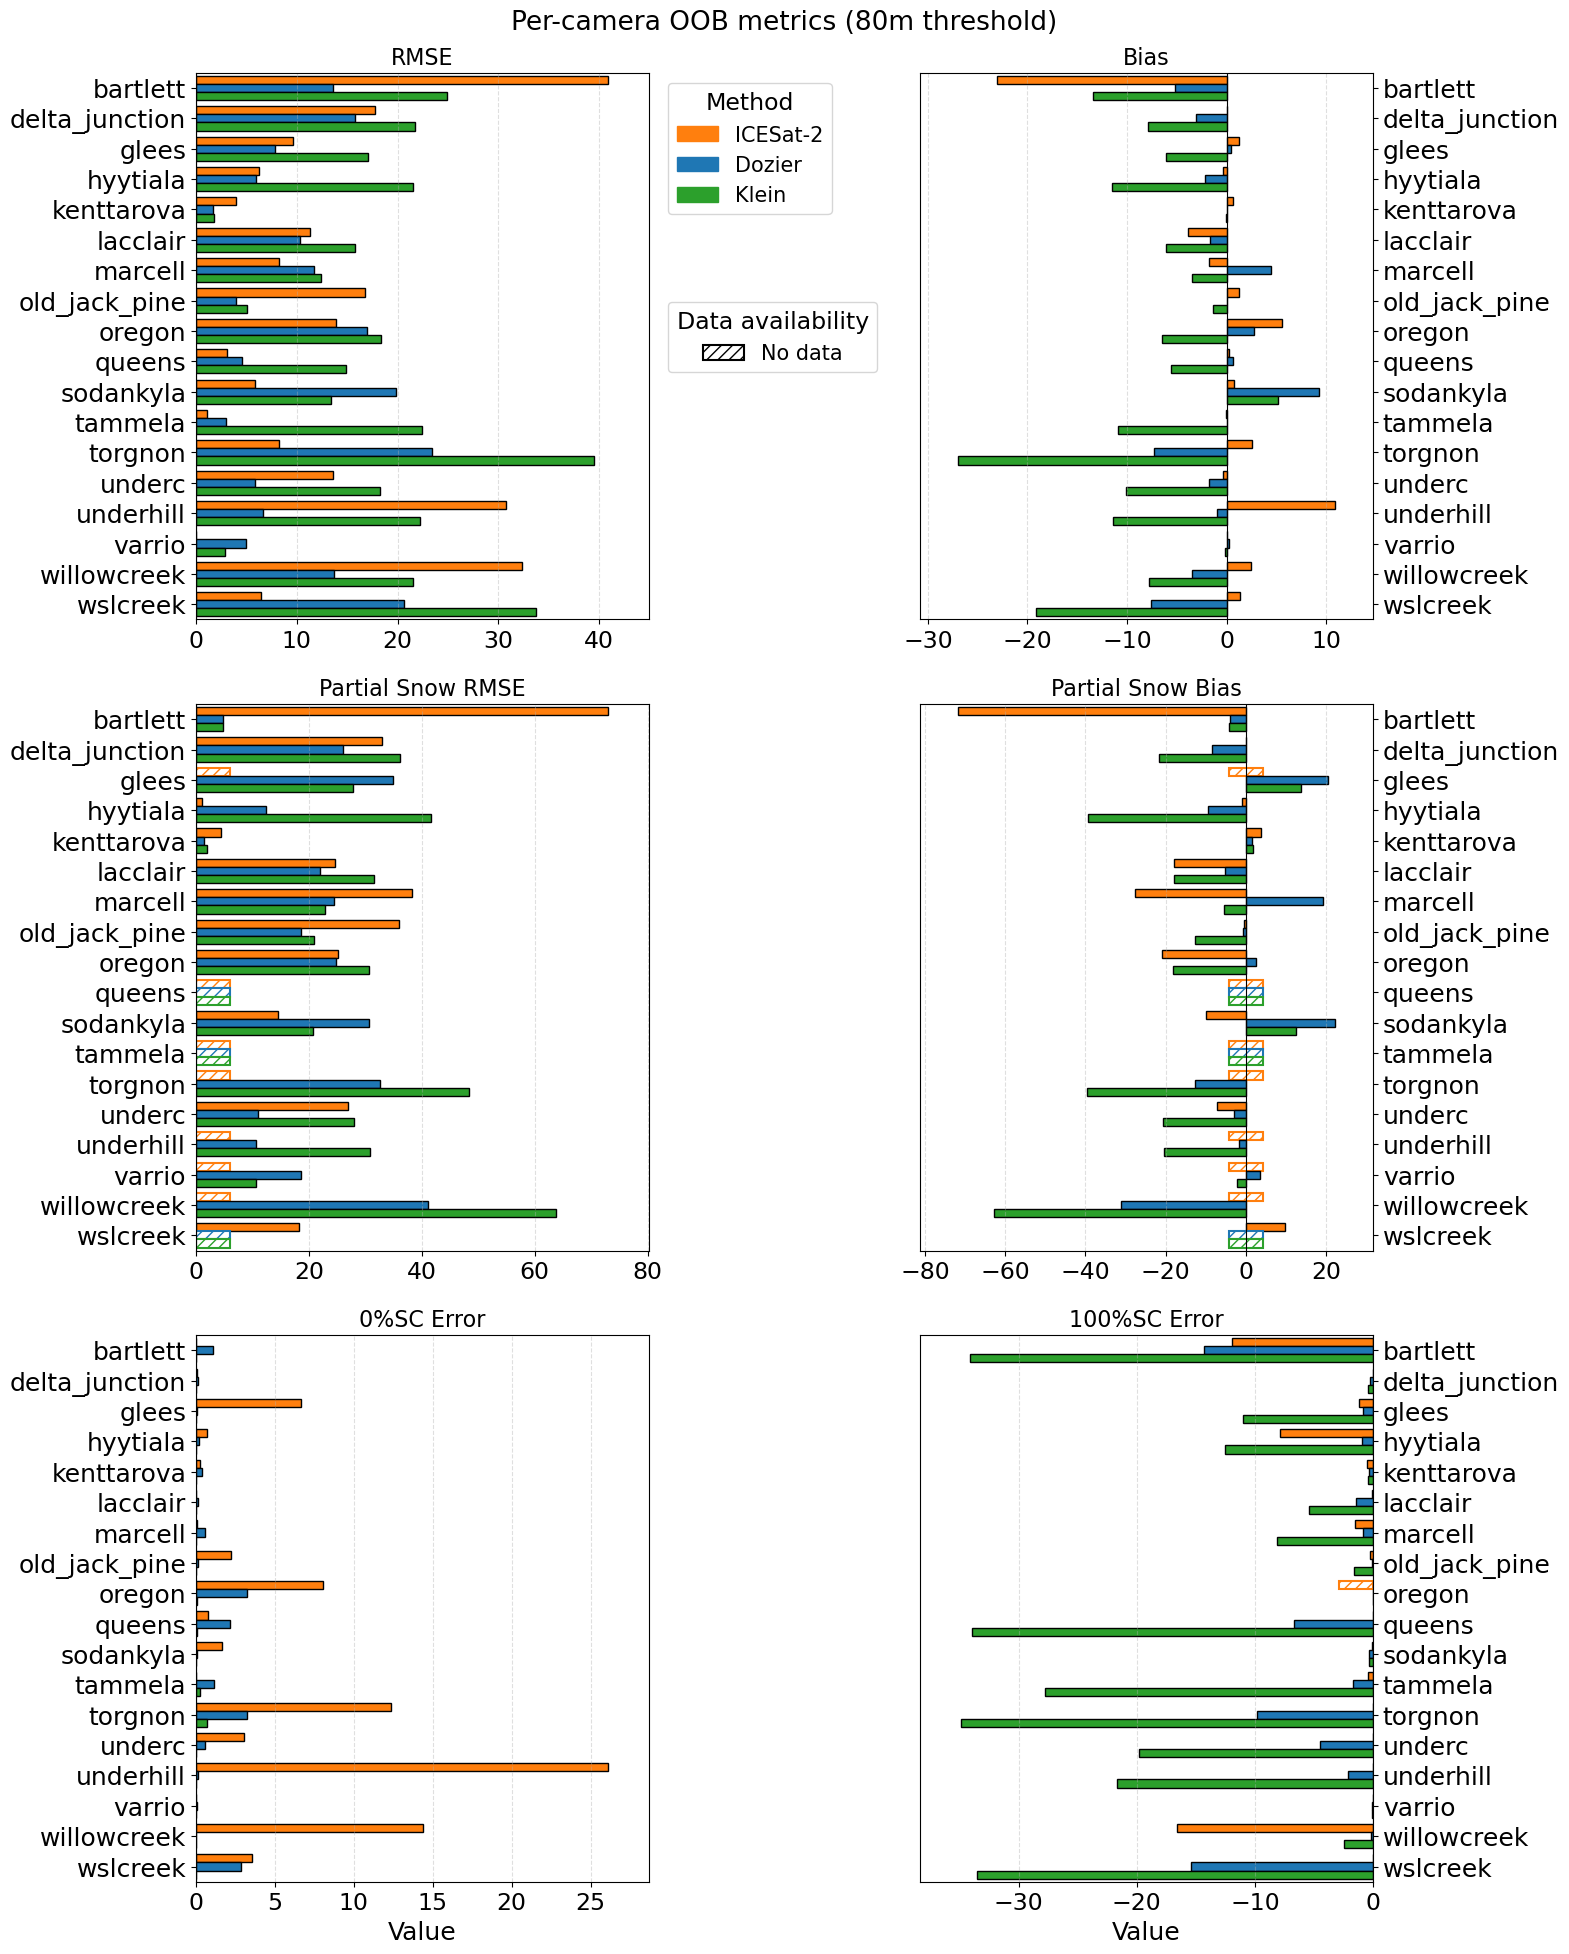

In [2]:
## with bartlett

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
import matplotlib.patches as mpatches


# ==========================
# 1. Build metrics dataframe
# ==========================

icesat2_txt = """\
bartlett 40.842825 -23.082608 72.909235 -71.777732 0.000000 -11.972360
delta_junction 17.792171 0.029856 32.884152 0.043003 0.045289 0.000000
glees 9.670686 1.219342 NaN NaN 6.676770 -1.216760
hyytiala 6.287877 -0.405992 1.000000 -1.000000 0.677864 -7.846208
kenttarova 3.964110 0.684203 4.506042 3.677798 0.263484 -0.517681
lacclair 11.306171 -3.840030 24.621526 -18.031922 0.000000 -0.102294
marcell_MN 8.258219 -1.788710 38.303089 -27.568800 0.058980 -1.488409
old_jack_pine 16.804509 1.190542 36.046879 -0.376685 2.216960 -0.269346
oregon_yp 13.908334 5.569471 25.226319 -20.963746 8.069573 NaN
queens 3.076889 0.273561 NaN NaN 0.749511 0.000000
sodankyla_full 5.830639 0.714659 14.588015 -9.906016 1.626504 -0.119520
tammela 1.139682 -0.103426 NaN NaN 0.005788 -0.458505
torgnon 8.215479 2.525294 NaN NaN 12.367175 0.000000
underc 13.642332 -0.361681 26.971754 -7.314769 3.049519 -0.018739
underhill 30.714154 10.905223 NaN NaN 26.078648 -0.000121
varrio 0.000000 0.000000 NaN NaN 0.000000 0.000000
willowcreek 32.369826 2.395107 NaN NaN 14.359939 -16.604333
wslcreek 6.404962 1.339762 18.238286 9.782197 3.544533 -0.001972
"""

df_ice = pd.read_csv(
    StringIO(icesat2_txt),
    sep=r"\s+",
    names=[
        "camera",
        "RMSE",
        "Bias",
        "Partial Snow RMSE",
        "Partial Snow Bias",
        "0%SC Error",
        "100%SC Error",
    ],
)
df_ice["method"] = "ICESat-2"

# normalise camera names
df_ice["camera"] = df_ice["camera"].replace({
    "marcell_MN": "marcell",
    "oregon_yp": "oregon",
    "sodankyla_full": "sodankyla",
})

# -------- Dozier + Klein block (second table) --------
optical_txt = """\
bartlett Dozier 13.586205 -5.217869 4.872099 -3.963662 1.108220 -14.325237
bartlett Klein 24.942261 -13.468992 4.842188 -4.323950 0.001521 -34.156719
delta_junction Dozier 15.738856 -3.093508 26.082893 -8.451213 0.144453 -0.267181
delta_junction Klein 21.748066 -7.943565 36.054587 -21.564507 0.012144 -0.389920
glees Dozier 7.840164 0.458636 34.921735 20.538290 0.044763 -0.863097
glees Klein 17.041197 -6.141285 27.885784 13.764996 0.000000 -10.979384
hyytiala Dozier 5.921860 -2.194299 12.437017 -9.387972 0.172087 -0.916593
hyytiala Klein 21.578118 -11.552141 41.675592 -39.468082 0.000000 -12.516552
kenttarova Dozier 1.730773 0.025580 1.478082 1.464854 0.351438 -0.378639
kenttarova Klein 1.757761 -0.095032 1.931629 1.839253 0.000000 -0.466825
lacclair Dozier 10.322806 -1.668166 22.012489 -5.193858 0.152663 -1.464487
lacclair Klein 15.745147 -6.137401 31.497109 -18.022963 0.000000 -5.450168
marcell Dozier 11.747728 4.412785 24.515747 19.159657 0.602453 -0.890667
marcell Klein 12.451359 -3.462936 22.869046 -5.495144 0.000000 -8.118144
old_jack_pine Dozier 3.925976 0.001366 18.577032 -0.604069 0.137148 -0.079376
old_jack_pine Klein 5.039998 -1.336042 20.948400 -12.614905 0.000000 -1.646734
oregon Dozier 16.954042 2.734434 24.794562 2.471382 3.242648 -0.016020
oregon Klein 18.363486 -6.490119 30.724133 -18.226440 0.036009 -0.017542
queens Dozier 4.536657 0.679288 NaN NaN 2.160689 -6.727717
queens Klein 14.840759 -5.596924 NaN NaN 0.069135 -33.927221
sodankyla Dozier 19.829709 9.262409 30.693948 22.282610 0.078218 -0.327617
sodankyla Klein 13.421181 5.128245 20.754315 12.445447 0.000000 -0.344150
tammela Dozier 2.951544 0.003609 NaN NaN 1.111848 -1.669875
tammela Klein 22.386042 -10.882490 NaN NaN 0.285916 -27.747231
torgnon Dozier 23.463537 -7.278681 32.533414 -12.612809 3.253996 -9.861009
torgnon Klein 39.533168 -26.980419 48.422475 -39.552654 0.710433 -34.858024
underc Dozier 5.882685 -1.763868 10.925293 -2.949653 0.593297 -4.458006
underc Klein 18.218199 -10.124878 28.056879 -20.635335 0.001628 -19.850287
underhill Dozier 6.641394 -0.929057 10.636151 -1.669365 0.129947 -2.083690
underhill Klein 22.194224 -11.421165 30.786196 -20.533590 0.000000 -21.660431
varrio Dozier 4.980908 0.227789 18.536619 3.416929 0.060317 -0.053929
varrio Klein 2.885547 -0.193458 10.713564 -2.162681 0.000000 -0.058556
willowcreek Dozier 13.710411 -3.506554 41.118956 -31.131375 0.024287 -0.183015
willowcreek Klein 21.537058 -7.788595 63.765695 -62.672716 0.000000 -2.474880
wslcreek Dozier 20.611041 -7.575802 NaN NaN 2.840634 -15.388129
wslcreek Klein 33.775638 -19.159235 NaN NaN 0.000000 -33.528662
"""

df_opt = pd.read_csv(
    StringIO(optical_txt),
    sep=r"\s+",
    names=[
        "camera",
        "method",
        "RMSE",
        "Bias",
        "Partial Snow RMSE",
        "Partial Snow Bias",
        "0%SC Error",
        "100%SC Error",
    ],
)

df_all = pd.concat([df_ice, df_opt], ignore_index=True)
df_all = df_all.sort_values(["camera", "method"]).reset_index(drop=True)

# ==========================
# 2. Plot with NaN placement logic (horizontal bars)
# ==========================

methods = ["ICESat-2", "Dozier", "Klein"]
method_colors = {
    "ICESat-2": "#ff7f0e",
    "Dozier":   "#1f77b4",
    "Klein":    "#2ca02c",
}

metrics_order = [
    "RMSE",
    "Bias",
    "Partial Snow RMSE",
    "Partial Snow Bias",
    "0%SC Error",
    "100%SC Error",
]

cams = sorted(df_all["camera"].unique())
n_cams = len(cams)
n_methods = len(methods)
y = np.arange(n_cams)
bar_height = 0.8 / n_methods

# Precompute metric ranges ignoring NaNs
metric_limits = {}
for metric in metrics_order:
    vals = df_all[metric].to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        vmin, vmax = -1.0, 1.0
    else:
        vmin, vmax = vals.min(), vals.max()
        if vmin == vmax:
            vmin -= 1.0
            vmax += 1.0
    metric_limits[metric] = (vmin, vmax)

# Apply font settings before creating the figure.
# Every font size is increased by 3 points.
plt.rcParams.update({
    "font.size": 17,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 15,
    "legend.title_fontsize": 17,
    "figure.titlesize": 20,
})
fig, axes = plt.subplots(3, 2, figsize=(16, 20))#, sharey=True)
axes = axes.ravel()

nan_frac = 0.075  # fraction of x-span used for NaN blocks

for idx, metric in enumerate(metrics_order):
    ax = axes[idx]
    vmin, vmax = metric_limits[metric]

    # Decide sign regime (zeros are neutral)
    vals = df_all[metric].to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    has_pos = np.any(vals > 0)
    has_neg = np.any(vals < 0)

    if has_pos and not has_neg:
        regime = "all_pos"
    elif has_neg and not has_pos:
        regime = "all_neg"
    else:
        regime = "mixed"  # any mix or only zeros

    # Choose x-limits and NaN block placement (horizontal version)
    if regime == "all_pos":
        xmin = 0.0
        xmax = vmax * 1.1
        span = xmax - xmin
        nan_length = nan_frac * span
        nan_left = 0.0                  # touches 0, extends positive
    elif regime == "all_neg":
        xmax = 0.0
        xmin = vmin * 1.1
        span = xmax - xmin
        nan_length = nan_frac * span
        nan_left = -nan_length          # from -L to 0
    else:  # mixed
        data_min = vmin
        data_max = vmax
        pad = 0.1 * (data_max - data_min if data_max != data_min else 1.0)
        xmin = data_min - pad
        xmax = data_max + pad
        span = xmax - xmin
        nan_length = nan_frac * span
        nan_left = -0.5 * nan_length    # centred on 0

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.5, n_cams - 0.5)

    for j, method in enumerate(methods):
        sub = (
            df_all[df_all["method"] == method]
            .set_index("camera")
            .reindex(cams)
        )
        vals_m = sub[metric].to_numpy(dtype=float)
        offset = (j - (n_methods - 1) / 2) * bar_height

        for cam_idx, val in enumerate(vals_m):
            yi = y[cam_idx] + offset

            if np.isnan(val):
                # NaN block in the correct method colour but hatched + white fill
                ax.barh(
                    yi,
                    nan_length,
                    left=nan_left,
                    height=bar_height,
                    facecolor="white",
                    edgecolor=method_colors[method],
                    hatch="///",
                    linewidth=1.5,
                )
            else:
                # Normal bar
                ax.barh(
                    yi,
                    val,
                    height=bar_height,
                    color=method_colors.get(method, None),
                    edgecolor="black",
                )

    ax.set_title(metric)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    if idx % 2 == 0:
        ax.set_yticks(y)
        ax.set_yticklabels(cams, fontsize=18)
        ax.invert_yaxis()
    else:
        ax.set_yticks(y)
        ax.set_yticklabels(cams, fontsize=18)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.invert_yaxis()

    if idx in (4, 5):  # bottom row
        ax.set_xlabel("Value", fontsize=18)

# -------- Split legends (methods + data availability) --------

# Method legend
method_patches = [
    mpatches.Patch(color=method_colors[m], label=m)
    for m in methods
]

leg1 = axes[0].legend(
    handles=method_patches,
    title="Method",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
)

# Generic NaN box (black outline, hatched)
nan_patch = mpatches.Patch(
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=1.5,
    label="No data",
)

leg2 = axes[0].legend(
    handles=[nan_patch],
    title="Data availability",
    bbox_to_anchor=(1.02, 0.6),
    loc="upper left",
)

axes[0].add_artist(leg1)

fig.suptitle("Per-camera OOB metrics (80m threshold)", fontsize=19)
plt.tight_layout()
plt.show()
# plt.savefig('./images/per-camera-OOB-metrics.svg')


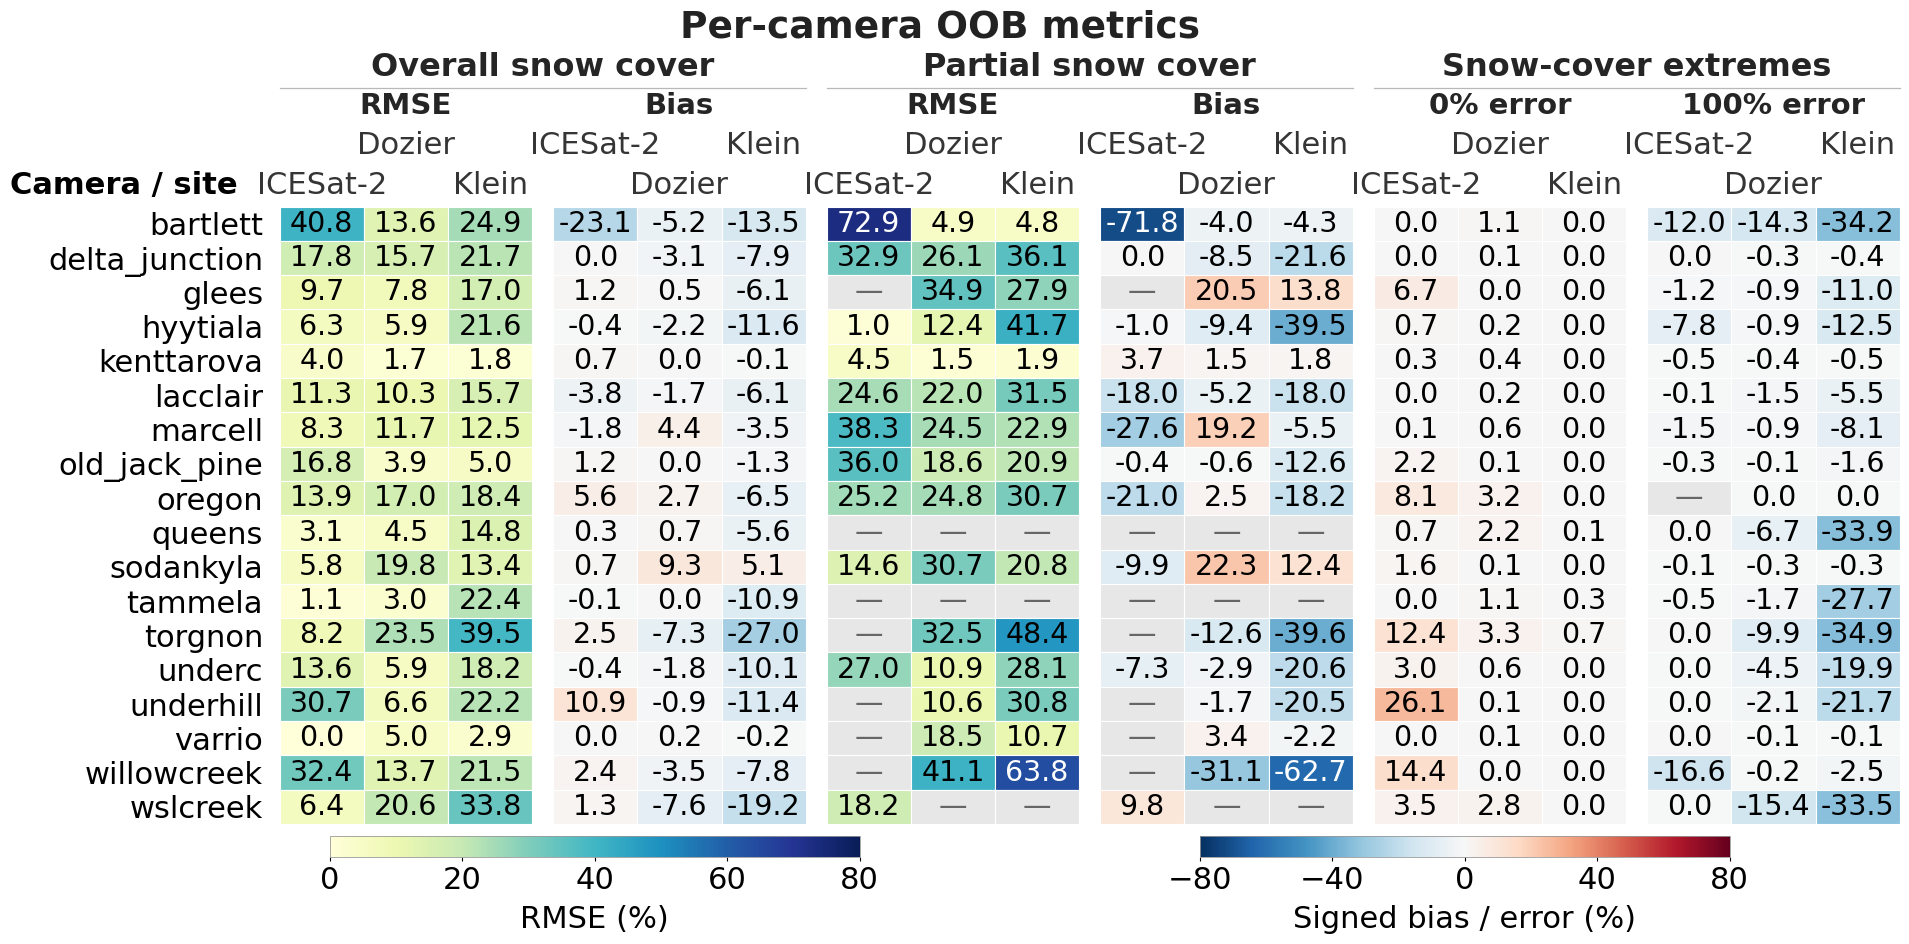

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable

# Font sizes in points.
FONT_SIZE = 19
METHOD_FONT = 22
SITE_FONT = 22
COLOURBAR_FONT = 22

ICESAT2_TEXT = """\
bartlett 40.842825 -23.082608 72.909235 -71.777732 0.000000 -11.972360
delta_junction 17.792171 0.029856 32.884152 0.043003 0.045289 0.000000
glees 9.670686 1.219342 NaN NaN 6.676770 -1.216760
hyytiala 6.287877 -0.405992 1.000000 -1.000000 0.677864 -7.846208
kenttarova 3.964110 0.684203 4.506042 3.677798 0.263484 -0.517681
lacclair 11.306171 -3.840030 24.621526 -18.031922 0.000000 -0.102294
marcell_MN 8.258219 -1.788710 38.303089 -27.568800 0.058980 -1.488409
old_jack_pine 16.804509 1.190542 36.046879 -0.376685 2.216960 -0.269346
oregon_yp 13.908334 5.569471 25.226319 -20.963746 8.069573 NaN
queens 3.076889 0.273561 NaN NaN 0.749511 0.000000
sodankyla_full 5.830639 0.714659 14.588015 -9.906016 1.626504 -0.119520
tammela 1.139682 -0.103426 NaN NaN 0.005788 -0.458505
torgnon 8.215479 2.525294 NaN NaN 12.367175 0.000000
underc 13.642332 -0.361681 26.971754 -7.314769 3.049519 -0.018739
underhill 30.714154 10.905223 NaN NaN 26.078648 -0.000121
varrio 0.000000 0.000000 NaN NaN 0.000000 0.000000
willowcreek 32.369826 2.395107 NaN NaN 14.359939 -16.604333
wslcreek 6.404962 1.339762 18.238286 9.782197 3.544533 -0.001972
"""

OPTICAL_TEXT = """\
bartlett Dozier 13.586205 -5.217869 4.872099 -3.963662 1.108220 -14.325237
bartlett Klein 24.942261 -13.468992 4.842188 -4.323950 0.001521 -34.156719
delta_junction Dozier 15.738856 -3.093508 26.082893 -8.451213 0.144453 -0.267181
delta_junction Klein 21.748066 -7.943565 36.054587 -21.564507 0.012144 -0.389920
glees Dozier 7.840164 0.458636 34.921735 20.538290 0.044763 -0.863097
glees Klein 17.041197 -6.141285 27.885784 13.764996 0.000000 -10.979384
hyytiala Dozier 5.921860 -2.194299 12.437017 -9.387972 0.172087 -0.916593
hyytiala Klein 21.578118 -11.552141 41.675592 -39.468082 0.000000 -12.516552
kenttarova Dozier 1.730773 0.025580 1.478082 1.464854 0.351438 -0.378639
kenttarova Klein 1.757761 -0.095032 1.931629 1.839253 0.000000 -0.466825
lacclair Dozier 10.322806 -1.668166 22.012489 -5.193858 0.152663 -1.464487
lacclair Klein 15.745147 -6.137401 31.497109 -18.022963 0.000000 -5.450168
marcell Dozier 11.747728 4.412785 24.515747 19.159657 0.602453 -0.890667
marcell Klein 12.451359 -3.462936 22.869046 -5.495144 0.000000 -8.118144
old_jack_pine Dozier 3.925976 0.001366 18.577032 -0.604069 0.137148 -0.079376
old_jack_pine Klein 5.039998 -1.336042 20.948400 -12.614905 0.000000 -1.646734
oregon Dozier 16.954042 2.734434 24.794562 2.471382 3.242648 -0.016020
oregon Klein 18.363486 -6.490119 30.724133 -18.226440 0.036009 -0.017542
queens Dozier 4.536657 0.679288 NaN NaN 2.160689 -6.727717
queens Klein 14.840759 -5.596924 NaN NaN 0.069135 -33.927221
sodankyla Dozier 19.829709 9.262409 30.693948 22.282610 0.078218 -0.327617
sodankyla Klein 13.421181 5.128245 20.754315 12.445447 0.000000 -0.344150
tammela Dozier 2.951544 0.003609 NaN NaN 1.111848 -1.669875
tammela Klein 22.386042 -10.882490 NaN NaN 0.285916 -27.747231
torgnon Dozier 23.463537 -7.278681 32.533414 -12.612809 3.253996 -9.861009
torgnon Klein 39.533168 -26.980419 48.422475 -39.552654 0.710433 -34.858024
underc Dozier 5.882685 -1.763868 10.925293 -2.949653 0.593297 -4.458006
underc Klein 18.218199 -10.124878 28.056879 -20.635335 0.001628 -19.850287
underhill Dozier 6.641394 -0.929057 10.636151 -1.669365 0.129947 -2.083690
underhill Klein 22.194224 -11.421165 30.786196 -20.533590 0.000000 -21.660431
varrio Dozier 4.980908 0.227789 18.536619 3.416929 0.060317 -0.053929
varrio Klein 2.885547 -0.193458 10.713564 -2.162681 0.000000 -0.058556
willowcreek Dozier 13.710411 -3.506554 41.118956 -31.131375 0.024287 -0.183015
willowcreek Klein 21.537058 -7.788595 63.765695 -62.672716 0.000000 -2.474880
wslcreek Dozier 20.611041 -7.575802 NaN NaN 2.840634 -15.388129
wslcreek Klein 33.775638 -19.159235 NaN NaN 0.000000 -33.528662
"""

# Prepare the data.
methods = ["ICESat-2", "Dozier", "Klein"]
metrics = [
    ("RMSE", "RMSE", "rmse"),
    ("Bias", "Bias", "signed"),
    ("Partial Snow RMSE", "RMSE", "rmse"),
    ("Partial Snow Bias", "Bias", "signed"),
    ("0%SC Error", "0% error", "signed"),
    ("100%SC Error", "100% error", "signed"),
]
metric_names = [m[0] for m in metrics]

df_ice = pd.read_csv(StringIO(ICESAT2_TEXT), sep=r"\s+", names=["camera", *metric_names])
df_ice["method"] = "ICESat-2"
df_opt = pd.read_csv(StringIO(OPTICAL_TEXT), sep=r"\s+", names=["camera", "method", *metric_names])
df_all = pd.concat([df_ice, df_opt], ignore_index=True)
df_all["camera"] = df_all["camera"].replace({
    "marcell_MN": "marcell", "oregon_yp": "oregon", "sodankyla_full": "sodankyla",
})
cams = sorted(df_all["camera"].unique())

# Shared colour scales, rounded up to the next 10.
rmse_columns = [m[0] for m in metrics if m[2] == "rmse"]
signed_columns = [m[0] for m in metrics if m[2] == "signed"]
rmse_max = max(10, np.ceil(np.nanmax(df_all[rmse_columns].values) / 10) * 10)
signed_max = max(10, np.ceil(np.nanmax(np.abs(df_all[signed_columns].values)) / 10) * 10)
norms = {
    "rmse": Normalize(0, rmse_max),
    "signed": TwoSlopeNorm(vmin=-signed_max, vcenter=0, vmax=signed_max),
}
cmaps = {"rmse": plt.get_cmap("YlGnBu"), "signed": plt.get_cmap("RdBu_r")}

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": FONT_SIZE,
    "svg.fonttype": "none", "figure.facecolor": "white", "axes.facecolor": "white",
})
fig = plt.figure(figsize=(20, 9.5))
ax = fig.add_axes([0.17, 0.135, 0.81, 0.65])
starts = np.arange(6) * 3.25
ax.set_xlim(-0.5, starts[-1] + 2.5)
ax.set_ylim(len(cams) - 0.5, -0.5)
ax.set_xticks([])
ax.set_yticks(np.arange(len(cams)))
ax.set_yticklabels(cams, fontsize=SITE_FONT)
ax.tick_params(axis="y", length=0, pad=12)
for spine in ax.spines.values():
    spine.set_visible(False)
header_transform = ax.get_xaxis_transform()

# Draw the cells and their values.
for k, (metric, label, kind) in enumerate(metrics):
    values = (
        df_all.pivot(index="camera", columns="method", values=metric)
        .reindex(index=cams, columns=methods).to_numpy()
    )
    for j, method in enumerate(methods):
        x = starts[k] + j
        header_y = 1.011 if (3 * k + j) % 2 == 0 else 1.075
        ax.text(x, header_y, method, transform=header_transform,
                ha="center", va="bottom", fontsize=METHOD_FONT,
                color="#353535", clip_on=False)
        for i, value in enumerate(values[:, j]):
            if np.isnan(value):
                colour, text, text_colour = "#e7e7e7", "—", "#666666"
            else:
                colour = cmaps[kind](norms[kind](value))
                text = f"{value if abs(value) >= 0.05 else 0:.1f}"
                # Choose black or white text for contrast with the cell.
                rgb = np.asarray(colour[:3])
                linear = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
                text_colour = "black" if np.dot(linear, [0.2126, 0.7152, 0.0722]) >= 0.179 else "white"
            ax.add_patch(Rectangle((x - 0.5, i - 0.5), 1, 1,
                                   facecolor=colour, edgecolor="white", linewidth=0.8))
            ax.text(x, i, text, ha="center", va="center",
                    fontsize=FONT_SIZE + 1.5, color=text_colour)
    ax.text(starts[k] + 1, 1.14, label, transform=header_transform,
            ha="center", va="bottom", fontsize=FONT_SIZE + 2,
            weight="bold", color="#252525", clip_on=False)

# Group headings.
for label, first, last in [
    ("Overall snow cover", 0, 1),
    ("Partial snow cover", 2, 3),
    ("Snow-cover extremes", 4, 5),
]:
    left, right = starts[first] - 0.5, starts[last] + 2.5
    ax.text((left + right) / 2, 1.2, label, transform=header_transform,
            ha="center", va="bottom", fontsize=FONT_SIZE + 4,
            weight="bold", color="#252525", clip_on=False)
    ax.plot([left, right], [1.192, 1.192], transform=header_transform,
            color="#b8b8b8", linewidth=0.9, clip_on=False)

ax.text(-1.0, 1.011, "Camera / site", transform=header_transform,
        ha="right", va="bottom", fontsize=SITE_FONT,
        weight="bold", clip_on=False)
fig.text(0.5, 0.973, "Per-camera OOB metrics", ha="center", va="center",
         fontsize=FONT_SIZE + 8, weight="bold", color="#222222")

# Colour bars.
for kind, position, label, ticks in [
    ("rmse", [0.195, 0.10, 0.265, 0.022],
     "RMSE (%)", np.linspace(0, rmse_max, 5)),
    ("signed", [0.63, 0.10, 0.265, 0.022],
     "Signed bias / error (%)", np.linspace(-signed_max, signed_max, 5)),
]:
    cbar = fig.colorbar(ScalarMappable(norm=norms[kind], cmap=cmaps[kind]),
                       cax=fig.add_axes(position), orientation="horizontal", ticks=ticks)
    cbar.set_label(label, fontsize=COLOURBAR_FONT, labelpad=7)
    cbar.ax.tick_params(labelsize=COLOURBAR_FONT, length=3)
    cbar.outline.set_linewidth(0.6)
    cbar.outline.set_edgecolor("#999999")

# Optional exports: uncomment the lines you want.
# fig.savefig("per_camera_metrics_heatmap.png", dpi=300)
# fig.savefig("per_camera_metrics_heatmap.svg")
plt.show()
